# Group 2

# Project: AI-Powered Job Scam Detection System

## Group Members

- Briannah Chelangat
- Christopher Karuiki
- Melisa Achieng
- Cleopas Karanja
- Alex Kinyua

---

## 1. Business Understanding

### 1.1 Business Problem

Kenya has experienced a significant rise in fraudulent job advertisements, particularly targeting unemployed youth seeking local and overseas employment opportunities. Fraudsters use fake job postings to:

- Collect application fees
- Steal personal information
- Conduct financial scams
- Facilitate human trafficking through fake overseas jobs

Current interventions are mainly reactive, where agencies are investigated or blacklisted after victims have already suffered losses. Job seekers lack a reliable tool that can assess the legitimacy of a job advertisement before they apply or pay money.

### 1.2 Business Objectives

The project seeks to:

#### Objective 1: Detect Fraudulent Job Advertisements

Develop a machine learning model that classifies job advertisements as: Genuine (0) or Fraudulent (1) using textual and structured job-posting information.

#### Objective 2: Identify Scam Patterns

Use NLP techniques to identify common scam indicators such as: Urgent hiring language, Upfront payment requests, Poorly written descriptions, Unrealistic salaries and Suspicious contact information.

#### Objective 3: Integrate Kenyan Government Verification

The system should verify:

- Whether a recruitment agency is licensed
- Whether the agency appears on government blacklists
- Whether the company exists in government records

#### Objective 4: Explain Predictions

Instead of only predicting fraud, the system should explain why a posting was flagged with reasons like ; Agency not found in NEA registry, Requests visa processing fee, Unrealistic overseas salary, Uses urgency phrases such as "Apply Immediately" e.t.c

### 1.3 Stakeholders

**Primary stakeholders**

1. **Job Seekers**  
   Use the system before applying for jobs. Helps them to avoid scams, protect personal data and avoid financial losses.
2. **Government Agencies**  
   Government agencies like National Employment Authority (NEA), Ministry of Labour and DCI will use the system to detect scam patterns earlier and monitor suspicious agencies.
3. **Recruitment Platforms**  
   Recruitment platforms like BrighterMonday, Fuzu and MyJobsInKenya will use the platform to automatically flag suspicious suspicious job posts before publication.

### 1.4 Success Criteria

The project will be considered successful if it achieves:

- **High Recall:** The model should identify most scam jobs.  
  Recall is important because missing a scam may result in real-world harm to users.
- **Good Precision:** Legitimate jobs should not be incorrectly flagged too often.
- **High F1 Score:** Balances precision and recall.
- **Strong ROC-AUC:** To measure overall classification performance.
- **Explainability:** Predictions should be understandable to non-technical users.

---

## 2. Data Understanding

### 2.1 Data Sources

- **Primary Dataset:** DIFrauD / EMSCAD
- **Dataset used for training had the following characteristics:**
  - 14,295 job postings
  - 599 fraudulent postings
  - 13,696 legitimate postings
- **Label:**
  - `1` = Fraudulent
  - `0` = Legitimate
- **Kenya Specific Verification Data:**
  - **NEA Recruitment Agency Register:** Used to determine whether an agency is licensed.
  - **DCI Blacklisted Agencies:** Used to identify agencies involved in fraud.
  - **Government Advisories:** Used to identify emerging scam patterns.
  - **Local Job Boards** like BrighterMonday, Fuzu and MyJobsInKenya: Used for future model adaptation.

### 2.2 Dataset Variables

The project standardizes job advertisements into a common structure such as:

| Variable | Description |
| --- | --- |
| `posting_id` | Unique job identifier |
| `title` | Job title |
| `description` | Job description |
| `company` | Hiring company |
| `agency` | Recruitment agency |
| `location` | Job location |
| `salary` | Salary offered |
| `employment_type` | Full-time, part-time, contract |
| `email` | Contact email |
| `source` | Source platform |
| `country` | Job destination country |
| `is_overseas` | Overseas job indicator |
| `fraud_label` | Target variable |

### 2.3 Exploratory Data Analysis (EDA)

**Key questions:**

- **Class Distribution:** How many jobs are fraud versus genuine?
- **Missing Values:** Which variables contain missing data?
- **Salary Analysis:** Do scam jobs offer unusually high salaries?
- **Text Analysis:** Which words frequently appear in scam advertisements? Examples: urgent, visa, fee, immediate and no experience.
- **Country Analysis:** Which overseas destinations are most commonly associated with suspicious advertisements?

---

## 3. Data Preparation

### 3.1 Data Cleaning

- **Remove Duplicates:** Many scam ads are reposted multiple times.
- **Handle Missing Values** like Missing salary, Missing company name and Missing agency information
- **Standardize Text by converting:** Uppercase to lowercase, Remove punctuation, Remove HTML tags and Remove special characters.

### 3.2 Feature Engineering

#### A. Text Features (NLP)

Transform text into machine-readable features.

**Methods:**

- **TF-IDF:** Measures the importance of words in a job advertisement.
- **Word Embeddings:** Capture semantic meaning.
- **Sentence Embeddings:** Used in transformer-based models.

#### B. Rule-Based Features

**Examples:**

| Rule | Flag |
| --- | --- |
| Contains "pay registration fee" | 1 |
| Contains "visa processing fee" | 1 |
| Uses Gmail instead of company domain | 1 |
| Unrealistic salary | 1 |
| Missing company information | 1 |

#### C. Government Verification Features

**Examples:**

| Feature | Meaning |
| --- | --- |
| `agency_verified` | Agency exists in NEA registry |
| `agency_blacklisted` | Agency appears on blacklist |
| `company_verified` | Company exists |

### 3.3 Dataset Integration (2-Class, Merged)

This notebook standardizes the available job-posting data, harmonizes labels, and exports one modelling-ready dataset.

**Target scheme:** `is_fraud` has two classes:

- **0: Legitimate**
- **1: Fraudulent or Fraud-risk**

> **Important:** real job-board postings are not automatically labeled legitimate. Their `is_fraud` remains `NaN` unless the project team approves that policy. EMSCAD provides real labels, while synthetic data provides generated training scenarios.

## 1. Data Cleaning - synthetic_40k.csv


In [92]:
import numpy as np
import pandas as pd

In [93]:
df1 = pd.read_csv('synthetic_40k.csv')
df1.shape

(40000, 13)

### 1.1 Initial inspection


In [94]:
print('Shape:', df1.shape)
print()
print(df1.dtypes)
print()
display(df1.head(10))

Shape: (40000, 13)

title                    str
company                  str
location                 str
industry_category        str
work_type                str
salary_range             str
experience_level         str
min_qualification        str
description              str
requirements             str
source_url           float64
source_platform          str
is_fraud               int64
dtype: object



,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,source_url,source_platform,is_fraud
0,HR Assistant,Vision Manpower Kenya,Kisumu,Insurance,Full-time,"KES 339,000/month",3-5 years,Certificate,"Immediate start, no interview needed! HR Assis...","No qualifications required, immediate hire.",NaN,Synthetic - AjiraCheck,2
1,Receptionist,Naivas Supermarket,Meru,Logistics,Full-time,"KES 35,000/month",Entry level,Certificate,Naivas Supermarket is seeking a qualified Rece...,Certificate required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
2,Cashier,Naivas Supermarket,Nyeri,Construction,Full-time,"KES 38,000/month",Entry level,Certificate,Naivas Supermarket is seeking a qualified Cash...,Bachelor's degree required. No experience requ...,NaN,Synthetic - AjiraCheck,0
3,Security Guard,Vision HR Consultants Ltd,Qatar,Logistics,Full-time,USD 829/month,1-3 years,Bachelor's degree,Vision HR Consultants Ltd is looking for a Sec...,Bachelor's degree required. Entry level prefer...,NaN,Synthetic - AjiraCheck,1
4,HR Assistant,Jubilee Insurance,Thika,Logistics,Full-time,"KES 83,000/month",3-5 years,Bachelor's degree,Jubilee Insurance is seeking a qualified HR As...,Bachelor's degree required. Entry level prefer...,NaN,Synthetic - AjiraCheck,0
5,Warehouse Supervisor,KenGen,Nairobi,Insurance,Full-time,"KES 43,000/month",Entry level,Diploma,KenGen is seeking a qualified Warehouse Superv...,KCSE certificate required. 3-5 years preferred.,NaN,Synthetic - AjiraCheck,0
6,Procurement Officer,Equity Bank Kenya,Meru,Retail,Full-time,"KES 48,000/month",1-3 years,Diploma,Equity Bank Kenya is seeking a qualified Procu...,Bachelor's degree required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,0
7,Caregiver,Ready Manpower Limited,Saudi Arabia,Manufacturing,Full-time,USD 741/month,No experience required,Bachelor's degree,Ready Manpower Limited is seeking a qualified ...,KCSE certificate required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
8,Domestic Worker,Top Level Management Ltd,United Arab Emirates,Telecommunications,Full-time,USD 428/month,3-5 years,KCSE certificate,Top Level Management Ltd is seeking a qualifie...,Certificate required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,0
9,Procurement Officer,Prime Manpower Services Ltd,Kisumu,Manufacturing,Contract,"KES 70,000/month",No experience required,KCSE certificate,Prime Manpower Services Ltd is looking for a P...,Bachelor's degree required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,1


### 1.2 Standardize column names

The dataset is standardized because it is built from very different sources: EMSCAD, five Kenyan job boards and two synthetic files. Each has its own column names, missing fields and labelling scheme, so they can only be stacked into one table once they share a common schema.


In [95]:
df1.columns = df1.columns.str.strip()
print(df1.columns.tolist())

['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'source_url', 'source_platform', 'is_fraud']


### 1.3 Trimming whitespace in text columns


In [96]:
text_cols_df1 = df1.select_dtypes(include='object').columns.tolist()
print('Text columns:', text_cols_df1)

for col in text_cols_df1:
    df1[col] = df1[col].astype('string').str.strip()

# Verify: count of remaining leading/trailing whitespace per column
ws_check = {col: (df1[col] != df1[col].str.strip()).sum() for col in text_cols_df1}
print('Remaining whitespace issues:', ws_check)

Text columns: ['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'source_platform']


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23432\2976624980.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols_df1 = df1.select_dtypes(include='object').columns.tolist()


Remaining whitespace issues: {'title': np.int64(0), 'company': np.int64(0), 'location': np.int64(0), 'industry_category': np.int64(0), 'work_type': np.int64(0), 'salary_range': np.int64(0), 'experience_level': np.int64(0), 'min_qualification': np.int64(0), 'description': np.int64(0), 'requirements': np.int64(0), 'source_platform': np.int64(0)}


`source_url` is null in the local synthetic file and carries no modelling information there, so the cleaning step removes fully null columns.


In [97]:
missing_df1 = df1.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df1.to_frame('missing_percent'))

fully_null_cols = missing_df1[missing_df1 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols)

df1 = df1.drop(columns=fully_null_cols)
print('Shape after dropping fully-null columns:', df1.shape)

,missing_percent
source_url,100.0
company,0.0
location,0.0
industry_category,0.0
title,0.0
work_type,0.0
salary_range,0.0
min_qualification,0.0
experience_level,0.0
description,0.0


Fully-null columns to drop: ['source_url']
Shape after dropping fully-null columns: (40000, 12)


### 1.5 Validate and cast "is_fraud"

Confirm the label only ever takes the values `0` (legitimate), `1` (suspicious), `2` (fraudulent) before casting to a small nullable integer type. Anything outside that set gets surfaced.


In [98]:
df1['is_fraud'] = pd.to_numeric(df1['is_fraud'], errors='coerce')

unexpected = df1.loc[~df1['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected.unique())

df1['is_fraud'] = df1['is_fraud'].astype('Int8')
print(df1['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    22857
1    11429
2     5714
Name: count, dtype: Int64


### 1.6 Duplicate check


In [99]:
exact_dupes = df1.duplicated().sum()
print('Fully-identical duplicate rows:', exact_dupes)

content_key = ['title', 'company', 'location', 'description']
near_dupes = df1[df1.duplicated(subset=content_key, keep=False)]
print('Rows sharing title+company+location+description (salary differs):', len(near_dupes))

conflict_check = near_dupes.groupby(content_key)['is_fraud'].nunique()
print('Groups with conflicting is_fraud labels:', (conflict_check > 1).sum())
before = len(df1)
df1 = df1.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Rows removed as exact duplicates: {before - len(df1)}')

Fully-identical duplicate rows: 0
Rows sharing title+company+location+description (salary differs): 530
Groups with conflicting is_fraud labels: 0
Rows removed as exact duplicates: 0


No fully-identical rows exist. There ARE 530 rows that share the same "title" / "company" / "location" / "description" but a different "salary_range"so these are kept rather than dropped.


### 1.7 Parse `salary_range` into numeric fields

For modelling, salary text is split into currency, numeric amount, and period. USD amounts are converted to Kenyan shillings using the explicit fixed rate below.


In [100]:
import re

USD_TO_KES = 130  # <- adjust this single constant if a different FX rate is needed

salary_pattern = re.compile(r'^(KES|USD)\s*([\d,]+)\s*/\s*(\w+)$', flags=re.IGNORECASE)

def parse_salary(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    m = salary_pattern.match(str(value).strip())
    if not m:
        return pd.Series([np.nan, np.nan, np.nan])
    currency, amount, period = m.groups()
    return pd.Series([currency.upper(), float(amount.replace(',', '')), period.lower()])

df1[['salary_currency', 'salary_amount', 'salary_period']] = df1['salary_range'].apply(parse_salary)

unparsed = df1['salary_range'].notna() & df1['salary_currency'].isna()
print('salary_range values that failed to parse:', unparsed.sum())
if unparsed.sum():
    display(df1.loc[unparsed, 'salary_range'].unique()[:10])

df1['salary_amount_kes'] = np.where(
    df1['salary_currency'] == 'USD',
    df1['salary_amount'] * USD_TO_KES,
    df1['salary_amount']
)

print(df1[['salary_range', 'salary_currency', 'salary_amount', 'salary_period', 'salary_amount_kes']].head())

salary_range values that failed to parse: 0
        salary_range salary_currency  salary_amount salary_period  \
0  KES 339,000/month             KES       339000.0         month   
1   KES 35,000/month             KES        35000.0         month   
2   KES 38,000/month             KES        38000.0         month   
3      USD 829/month             USD          829.0         month   
4   KES 83,000/month             KES        83000.0         month   

   salary_amount_kes  
0           339000.0  
1            35000.0  
2            38000.0  
3           107770.0  
4            83000.0  


### 1.8 Validate categorical fields

Full value set for each categorical column so any typo, stray category, or unexpected value is caught before modelling.


In [101]:
categorical_cols_df1 = ['work_type', 'experience_level', 'min_qualification', 'industry_category']

for col in categorical_cols_df1:
    print(f'{col} ({df1[col].nunique()} unique values)')
    print(df1[col].value_counts(dropna=False))
    print()

work_type (2 unique values)
work_type
Full-time    30028
Contract      9972
Name: count, dtype: Int64

experience_level (4 unique values)
experience_level
No experience required    10104
3-5 years                  9981
Entry level                9977
1-3 years                  9938
Name: count, dtype: Int64

min_qualification (4 unique values)
min_qualification
KCSE certificate     10140
Diploma              10024
Certificate           9960
Bachelor's degree     9876
Name: count, dtype: Int64

industry_category (9 unique values)
industry_category
Healthcare            4499
Manufacturing         4496
Retail                4475
Telecommunications    4465
Hospitality           4464
Banking & Finance     4439
Logistics             4425
Insurance             4371
Construction          4366
Name: count, dtype: Int64



### 1.9 Final check and export


In [102]:
print('Final shape:', df1.shape)
print()
print('Remaining missing values:')
display(df1.isna().sum().to_frame('missing_count'))

df1.to_csv('synthetic_40k_clean.csv', index=False)
print("\nSaved: synthetic_40k_clean.csv")
df1.duplicated().sum()

Final shape: (40000, 16)

Remaining missing values:


,missing_count
title,0
company,0
location,0
industry_category,0
work_type,0
salary_range,0
experience_level,0
min_qualification,0
description,0
requirements,0



Saved: synthetic_40k_clean.csv


np.int64(0)

## 2. Data cleaning of the local synthetic augmentation view (`df2`)


In [103]:
df2 = pd.read_csv('synthetic_augmentation_postings.csv')
print('Shape:', df2.shape)
print()
print(df2.dtypes)
print()
display(df2.head(3))

Shape: (5000, 14)

posting_id             str
title                  str
description            str
company                str
agency             float64
location               str
salary             float64
employment_type        str
email                  str
source             float64
country                str
is_overseas            str
is_fraud             int64
data_source            str
dtype: object



,posting_id,title,description,company,agency,location,salary,employment_type,email,source,country,is_overseas,is_fraud,data_source
0,SYN-000000,Customer Service Agent,Salary is commensurate with experience and wil...,"Williams, Nicholson and Davis",NaN,Machakos,NaN,Full-time,browningjason@hamilton.com,NaN,Kenya,No,0,synthetic_augmentation
1,SYN-000001,Data Entry Clerk,We are looking for a Data Entry Clerk to join ...,"Martinez, Walker and Burton",NaN,Kakamega,NaN,Part-time,rayrandy@williams.com,NaN,Kenya,No,0,synthetic_augmentation
2,SYN-000002,Sales Representative,Minimum requirements: a diploma or degree in a...,"Parker, Cabrera and White",NaN,Kakamega,NaN,Full-time,nathankelley@elliott.com,NaN,Kenya,No,0,synthetic_augmentation


### 2.1 Standardize column names and trim text fields


In [104]:
df2.columns = df2.columns.str.strip()

text_cols_df2 = df2.select_dtypes(include='object').columns.tolist()
print('Text columns:', text_cols_df2)

for col in text_cols_df2:
    df2[col] = df2[col].astype('string').str.strip()

Text columns: ['posting_id', 'title', 'description', 'company', 'location', 'employment_type', 'email', 'country', 'is_overseas', 'data_source']


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23432\463795552.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols_df2 = df2.select_dtypes(include='object').columns.tolist()


### 2.2 Missing-value


In [105]:
missing_df2 = df2.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df2.to_frame('missing_percent'))

fully_null_cols_df2 = missing_df2[missing_df2 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols_df2)
df2 = df2.drop(columns=fully_null_cols_df2)

df2['has_email'] = df2['email'].notna()
df2['email'] = df2['email'].fillna('not_provided')

print('\nShape after cleanup:', df2.shape)
print(df2['has_email'].value_counts())

,missing_percent
agency,100.00
salary,100.00
source,100.00
email,14.84
title,0.00
posting_id,0.00
location,0.00
company,0.00
description,0.00
employment_type,0.00


Fully-null columns to drop: ['agency', 'salary', 'source']

Shape after cleanup: (5000, 12)
has_email
True     4258
False     742
Name: count, dtype: int64


"agency", "salary", and "source" are 100% null across all 5,000 rows and so we drop them.

"email" is missing for ~15% of rows. Rather than dropping those rows, a "has_email" flag is kept and the NaNs are filled with an explicit placeholder instead of silently left blank.


### 2.3 Validate email format

Sanity-check every non-placeholder email against a basic "local@domain.tld" pattern and flag anything that doesn't match instead of assuming the column is clean.


In [106]:
email_pattern = re.compile(r'^[^@\s]+@[^@\s]+\.[^@\s]+$')

real_emails = df2.loc[df2['has_email'], 'email']
invalid_emails = real_emails[~real_emails.str.match(email_pattern)]
print(f'Invalid email formats: {len(invalid_emails)} out of {len(real_emails)}')
if len(invalid_emails):
    display(invalid_emails.head(10))

Invalid email formats: 0 out of 4258


### 2.4 Validate and cast 'is_fraud'


In [107]:
df2['is_fraud'] = pd.to_numeric(df2['is_fraud'], errors='coerce')

unexpected_df2 = df2.loc[~df2['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected_df2.unique())

df2['is_fraud'] = df2['is_fraud'].astype('Int8')
print(df2['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    4258
1     535
2     207
Name: count, dtype: Int64


### 2.5 Check zero-variance columns

The local augmentation view includes constant `country` and `is_overseas` fields. They are retained here because their value may vary when other sources are combined.


In [108]:
for col in ['country', 'is_overseas']:
    print(f'{col}: {df2[col].nunique()} unique value(s) -> {df2[col].unique()}')

country: 1 unique value(s) -> <StringArray>
['Kenya']
Length: 1, dtype: string
is_overseas: 1 unique value(s) -> <StringArray>
['No']
Length: 1, dtype: string


### 2.6 Remove duplicate postings

Duplicate checking is performed on the available content fields and the cleaning output reports the rows removed.


In [109]:
content_key_df2 = ['title', 'company', 'location', 'description']

dupe_mask = df2.duplicated(subset=content_key_df2, keep=False)
print('Rows involved in content duplicates:', dupe_mask.sum())
display(df2.loc[dupe_mask, ['posting_id'] + content_key_df2 + ['is_fraud']].sort_values(content_key_df2))
before_df2 = len(df2)
df2 = df2.drop_duplicates(subset=content_key_df2, keep='first').reset_index(drop=True)
print(f'\nRows removed as duplicate postings: {before_df2 - len(df2)}')

Rows involved in content duplicates: 20


,posting_id,title,company,location,description,is_fraud
2055,SYN-002055,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant ...,1
4341,SYN-004341,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant ...,1
2226,SYN-002226,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant ...,1
2257,SYN-002257,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant ...,1
4663,SYN-004663,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and wil...,1
4769,SYN-004769,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and wil...,1
1931,SYN-001931,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join o...,1
4717,SYN-004717,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join o...,1
948,SYN-000948,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join o...,1
2449,SYN-002449,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join o...,1



Rows removed as duplicate postings: 10


### 2.7 Final check and export


In [110]:
print('Final shape:', df2.shape)
print()
print('Remaining missing values:')
display(df2.isna().sum().to_frame('missing_count'))

df2.to_csv('synthetic_augmentation_postings_clean.csv', index=False)
print("\nSaved: synthetic_augmentation_postings_clean.csv")
df2.duplicated().sum()

Final shape: (4990, 12)

Remaining missing values:


,missing_count
posting_id,0
title,0
description,0
company,0
location,0
employment_type,0
email,0
country,0
is_overseas,0
is_fraud,0



Saved: synthetic_augmentation_postings_clean.csv


np.int64(0)

## 3. Load the datasets

The available source files are loaded directly from the portable raw-data directory.

In [111]:
from pathlib import Path

# Resolve the repository root so paths work whether the kernel starts in
# notebooks/ or at the repository root.
# RAW = Path("data/raw")
# if not RAW.exists():
#     RAW = Path("..") / "data" / "raw"

# Six original datasets
df_fake = pd.read_csv("fake_job_postings.csv")
df_fuzu = pd.read_csv("fuzu_kenya_jobs.csv")
df_pigia = pd.read_csv("pigiame_jobs_full.csv")
df_corp = pd.read_csv("corporatestaffing_jobs_full.csv")
df_bm = pd.read_csv("brightermonday_kenya_jobs.csv")
df_jobweb = pd.read_csv("jobwebkenya_jobs_full.csv")

# Synthetic dataset, already uses the 3-class is_fraud scheme (0/1/2)
df_synthetic = pd.read_csv("synthetic_40k.csv")

datasets = {
    "Fake Job Postings": df_fake,
    "Fuzu Kenya": df_fuzu,
    "PigiaMe Kenya": df_pigia,
    "Corporate Staffing Kenya": df_corp,
    "BrighterMonday Kenya": df_bm,
    "JobWeb Kenya": df_jobweb,
    "Synthetic Augmentation": df_synthetic,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fake Job Postings: (17880, 18)
Fuzu Kenya: (666, 7)
PigiaMe Kenya: (1500, 8)
Corporate Staffing Kenya: (3988, 7)
BrighterMonday Kenya: (1964, 13)
JobWeb Kenya: (5323, 9)
Synthetic Augmentation: (40000, 13)


### Merging the datasets
Loading the seven raw datasets and mapping each one into a single shared 14-column schema, since the sources are structurally incompatible — EMSCAD calls its label fraudulent and its company field company_profile, Fuzu stores category in tags, PigiaMe has no industry field at all, and the synthetic file already uses different column names again. It fills unmapped fields with NaN rather than guessing, so missing information stays honest instead of encoding which job board a row came from.

In [112]:
# Load the seven sources
df_fake      = pd.read_csv("fake_job_postings.csv")
df_fuzu      = pd.read_csv("fuzu_kenya_jobs.csv")
df_pigia     = pd.read_csv("pigiame_jobs_full.csv")
df_corp      = pd.read_csv("corporatestaffing_jobs_full.csv")
df_bm        = pd.read_csv("brightermonday_kenya_jobs.csv")
df_jobweb    = pd.read_csv("jobwebkenya_jobs_full.csv")
df1          = pd.read_csv("synthetic_40k.csv")   

for df in (df_fake, df_fuzu, df_pigia, df_corp, df_bm, df_jobweb, df1):
    df.columns = df.columns.str.strip()

# Standardize into the shared schema 
SCHEMA = [
    "title", "company", "location", "industry_category", "work_type",
    "salary_range", "experience_level", "min_qualification",
    "description", "requirements", "source_url", "source_platform",
    "is_fraud", "data_source",
]

def standardize(source, mapping, platform, data_source="original"):
    """Build one schema-shaped frame; unmapped fields become NaN."""
    out = pd.DataFrame(index=source.index)
    for column in SCHEMA:
        value = mapping.get(column, np.nan)
        out[column] = source[value] if isinstance(value, str) else value
    out["source_platform"] = platform
    out["data_source"] = data_source
    return out

df_fake_std = standardize(df_fake, {
    "title": "title", "company": "company_profile", "location": "location",
    "industry_category": "industry", "work_type": "employment_type",
    "salary_range": "salary_range", "experience_level": "required_experience",
    "min_qualification": "required_education", "description": "description",
    "requirements": "requirements", "is_fraud": "fraudulent",
}, "Fake Job Postings Dataset")

df_fuzu_std = standardize(df_fuzu, {
    "title": "title", "company": "company", "location": "location",
    "industry_category": "tags", "salary_range": "salary_range",
    "description": "description", "source_url": "source_url",
}, "Fuzu Kenya")

df_pigia_std = standardize(df_pigia, {
    "title": "title", "company": "company", "location": "location",
    "work_type": "work_type", "salary_range": "salary_range",
    "description": "description", "source_url": "source_url",
}, "PigiaMe Kenya")

df_corp_std = standardize(df_corp, {
    "title": "title", "location": "location", "industry_category": "industry",
    "salary_range": "salary_range", "description": "description",
    "source_url": "source_url",
}, "Corporate Staffing Kenya")

df_bm_std = standardize(df_bm, {
    "title": "title", "company": "company", "location": "location",
    "industry_category": "category", "work_type": "work_type",
    "salary_range": "salary_range", "experience_level": "experience_level",
    "min_qualification": "min_qualification", "description": "description",
    "source_url": "source_url",
}, "BrighterMonday Kenya")

df_jobweb_std = standardize(df_jobweb, {
    "title": "title", "company": "company", "location": "location",
    "industry_category": "job_category", "work_type": "job_type",
    "description": "description", "source_url": "source_url",
}, "JobWeb Kenya")

df_synthetic_std = standardize(df1, {
    "title": "title", "company": "company", "location": "location",
    "industry_category": "industry_category", "work_type": "work_type",
    "salary_range": "salary_range", "experience_level": "experience_level",
    "min_qualification": "min_qualification", "description": "description",
    "requirements": "requirements", "is_fraud": "is_fraud",
}, "Synthetic", data_source="synthetic")

# Combine
final_df = pd.concat(
    [df_fake_std, df_fuzu_std, df_pigia_std, df_corp_std,
     df_bm_std, df_jobweb_std, df_synthetic_std],
    ignore_index=True,
)

# Harmonize is_fraud into three classes
final_df["is_fraud"] = pd.to_numeric(final_df["is_fraud"], errors="coerce")
is_emscad = final_df["source_platform"] == "Fake Job Postings Dataset"
final_df.loc[is_emscad, "is_fraud"] = final_df.loc[is_emscad, "is_fraud"].map({0: 0, 1: 2})

class_names = {0: "Legitimate", 1: "Suspicious", 2: "Fraudulent / Scam"}

# Remove exact duplicates
final_df = final_df.drop_duplicates(
    subset=["title", "company", "location", "description"], keep="first"
).reset_index(drop=True)

print("final_df shape:", final_df.shape)
print(final_df["is_fraud"].value_counts(dropna=False).sort_index())

final_df shape: (70302, 14)
is_fraud
0.0    39219
1.0    11426
2.0     6505
NaN    13152
Name: count, dtype: int64


### Near-duplicate removal
This cell fingerprints each posting by normalizing and hashing its title, description, and requirements text, then removes near-duplicates. This prevents leakage by making sure no two near-identical postings can ever end up on opposite sides of a data split

In [113]:
import hashlib

import pandas as pd

# Near-duplicate removal for the merged dataset.
# Uses the same normalization as the fingerprint cell in 4.3, so both agree.

DEDUP_TEXT_COLUMNS = ["title", "description", "requirements"]

rows_before = len(final_df)
dedup_df = final_df.copy()


# 1. Fingerprint every posting from its normalized text

normalized_text = (
    dedup_df["title"].fillna("").astype(str)
    + " "
    + dedup_df["description"].fillna("").astype(str)
    + " "
    + dedup_df["requirements"].fillna("").astype(str)
).str.lower()

normalized_text = (
    normalized_text
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Rows with no usable text get no fingerprint, so they are never treated
# as duplicates of each other.
dedup_df["fingerprint"] = normalized_text.map(
    lambda text: hashlib.md5(text.encode("utf-8")).hexdigest() if text else pd.NA
)


# 2. Describe each row: synthetic or real, labelled or unlabelled

is_synthetic = (
    dedup_df["data_source"].fillna("").astype(str).str.lower().str.contains("synthetic")
    | dedup_df["source_platform"].fillna("").astype(str).str.lower().str.contains("synthetic")
)
is_labelled = dedup_df["is_fraud"].notna()
fraud_risk = (dedup_df["is_fraud"] > 0).astype(int) 


# 3. Remove duplicate families whose real labelled copies disagree

real_labelled = dedup_df["fingerprint"].notna() & ~is_synthetic & is_labelled

labels_per_fingerprint = (
    dedup_df.loc[real_labelled, ["fingerprint"]]
    .assign(fraud_risk=fraud_risk[real_labelled])
    .groupby("fingerprint")["fraud_risk"]
    .nunique()
)

conflicting_fingerprints = set(labels_per_fingerprint[labels_per_fingerprint > 1].index)
in_conflicting_family = dedup_df["fingerprint"].isin(conflicting_fingerprints)

print("Conflicting-label duplicate families removed:", len(conflicting_fingerprints))
print("Rows removed with those families:", int(in_conflicting_family.sum()))

deduped = dedup_df[~in_conflicting_family].copy()


# 4. Keep one row per fingerprint: real before synthetic, labelled before unlabelled

deduped["_priority"] = (
    is_synthetic.loc[deduped.index].astype(int) * 2
    + (~is_labelled.loc[deduped.index]).astype(int)
)

with_text = (
    deduped[deduped["fingerprint"].notna()]
    .sort_values("_priority", kind="mergesort")
    .drop_duplicates(subset="fingerprint", keep="first")
)
without_text = deduped[deduped["fingerprint"].isna()]

assert not with_text["fingerprint"].duplicated().any(), "Duplicate fingerprints remain"


# 5. Rebuild final_df in its original row order, without the helper columns

final_df = (
    pd.concat([with_text, without_text])
    .sort_index()
    .drop(columns=["fingerprint", "_priority"])
    .reset_index(drop=True)
)

near_duplicates_removed = (
    rows_before - int(in_conflicting_family.sum()) - len(final_df)
)

print("\nRows before near-duplicate removal:", rows_before)
print("Near-duplicate rows removed:", near_duplicates_removed)
print("Rows after near-duplicate removal:", len(final_df))
print("\nRows per source after de-duplication:")
display(final_df["source_platform"].value_counts())


Conflicting-label duplicate families removed: 0
Rows removed with those families: 0

Rows before near-duplicate removal: 70302
Near-duplicate rows removed: 2258
Rows after near-duplicate removal: 68044

Rows per source after de-duplication:


source_platform
Synthetic                    39432
Fake Job Postings Dataset    15555
JobWeb Kenya                  5249
Corporate Staffing Kenya      3982
BrighterMonday Kenya          1930
PigiaMe Kenya                 1230
Fuzu Kenya                     666
Name: count, dtype: int64

## 4. Clean column names

In [114]:
for df in datasets.values():
    df.columns = df.columns.str.strip()

for name, df in datasets.items():
    print(f'\n{name}')
    print(df.columns.tolist())


Fake Job Postings
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Fuzu Kenya
['title', 'company', 'location', 'salary_range', 'tags', 'description', 'source_url']

PigiaMe Kenya
['title', 'company', 'work_type', 'location', 'salary_range', 'posted', 'description', 'source_url']

Corporate Staffing Kenya
['title', 'industry', 'salary_range', 'location', 'deadline', 'description', 'source_url']

BrighterMonday Kenya
['title', 'company', 'category', 'location', 'work_type', 'salary_range', 'min_qualification', 'experience_level', 'experience_length', 'language_requirement', 'working_hours', 'description', 'source_url']

JobWeb Kenya
['title', 'company', 'location', 'state', 'job_type', 'job_category', 'closing_date', 'description', 'source_url']

Synthetic Au

## 5. Standardize each dataset into a common schema

The dataset is standardized because it is built from very different sources: EMSCAD, five Kenyan job boards and two synthetic files. Each has its own column names, missing fields and labelling scheme, so they can only be stacked into one table once they share a common schema.

Each source is mapped into the same set of columns. Fields that source
doesn't have information are filled with `NaN` rather than guessed.


In [115]:
# 1. Fake Job Postings (EMSCAD) -- has genuine ground-truth labels
df_fake_std = pd.DataFrame({
    'title': df_fake['title'],
    'company': df_fake['company_profile'],
    'location': df_fake['location'],
    'industry_category': df_fake['industry'],
    'work_type': df_fake['employment_type'],
    'salary_range': df_fake['salary_range'],
    'experience_level': df_fake['required_experience'],
    'min_qualification': df_fake['required_education'],
    'description': df_fake['description'],
    'requirements': df_fake['requirements'],
    'source_url': np.nan,
    'source_platform': 'Fake Job Postings Dataset',
    'is_fraud': df_fake['fraudulent'],   # real label, recovered from the original column
    'data_source': 'original',
})

# 2. Fuzu Kenya -- no fraud label available
df_fuzu_std = pd.DataFrame({
    'title': df_fuzu['title'],
    'company': df_fuzu['company'],
    'location': df_fuzu['location'],
    'industry_category': df_fuzu['tags'],
    'work_type': np.nan,
    'salary_range': df_fuzu['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_fuzu['description'],
    'requirements': np.nan,
    'source_url': df_fuzu['source_url'],
    'source_platform': 'Fuzu Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 3. PigiaMe Kenya -- no fraud label available
df_pigia_std = pd.DataFrame({
    'title': df_pigia['title'],
    'company': df_pigia['company'],
    'location': df_pigia['location'],
    'industry_category': np.nan,
    'work_type': df_pigia['work_type'],
    'salary_range': df_pigia['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_pigia['description'],
    'requirements': np.nan,
    'source_url': df_pigia['source_url'],
    'source_platform': 'PigiaMe Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 4. Corporate Staffing Kenya -- no fraud label available
df_corp_std = pd.DataFrame({
    'title': df_corp['title'],
    'company': np.nan,
    'location': df_corp['location'],
    'industry_category': df_corp['industry'],
    'work_type': np.nan,
    'salary_range': df_corp['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_corp['description'],
    'requirements': np.nan,
    'source_url': df_corp['source_url'],
    'source_platform': 'Corporate Staffing Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


In [116]:
# 5. BrighterMonday Kenya -- no fraud label available
df_bm_std = pd.DataFrame({
    'title': df_bm['title'],
    'company': df_bm['company'],
    'location': df_bm['location'],
    'industry_category': df_bm['category'],
    'work_type': df_bm['work_type'],
    'salary_range': df_bm['salary_range'],
    'experience_level': df_bm['experience_level'],
    'min_qualification': df_bm['min_qualification'],
    'description': df_bm['description'],
    'requirements': np.nan,
    'source_url': df_bm['source_url'],
    'source_platform': 'BrighterMonday Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


In [117]:
# 6. JobWeb Kenya -- no fraud label available
df_jobweb_std = pd.DataFrame({
    'title': df_jobweb['title'],
    'company': df_jobweb['company'],
    'location': df_jobweb['location'],
    'industry_category': df_jobweb['job_category'],
    'work_type': df_jobweb['job_type'],
    'salary_range': np.nan,
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_jobweb['description'],
    'requirements': np.nan,
    'source_url': df_jobweb['source_url'],
    'source_platform': 'JobWeb Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


## 6. Standardize the synthetic dataset

`synthetic_40k.csv` already uses the standard column names and the 0/1/2 label scheme, so this is a pass-through with a `data_source` tag.


In [118]:
df_synthetic_std = pd.DataFrame({
    'title': df1['title'],
    'company': df1['company'],
    'location': df1['location'],
    'industry_category': df1['industry_category'],
    'work_type': df1['work_type'],
    'salary_range': df1['salary_range'],
    'experience_level': df1['experience_level'],
    'min_qualification': df1['min_qualification'],
    'description': df1['description'],
    'requirements': df1['requirements'],
    'source_url': np.nan,
    'source_platform': 'Synthetic',
    'is_fraud': df1['is_fraud'],   # already 0 / 1 / 2 -- no remapping needed
    'data_source': 'synthetic',
})


## 7. Combine all datasets

Every available source now shares the standardized schema, so the rows are stacked.


In [119]:
final_df = pd.concat(
    [df_fake_std, df_fuzu_std, df_pigia_std, df_corp_std, df_bm_std, df_jobweb_std, df_synthetic_std],
    ignore_index=True
)

print('Combined shape:', final_df.shape)
final_df.head(3)


Combined shape: (71321, 14)


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,source_url,source_platform,is_fraud,data_source
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,Fake Job Postings Dataset,0.0,original
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,NaN,Fake Job Postings Dataset,0.0,original
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,Fake Job Postings Dataset,0.0,original


We combine labeled EMSCAD data, synthetic Kenya-market postings, and unlabeled job-board data. A real labeled holdout is carved out before modelling and reserved for final evaluation.


## 8. Harmonize `is_fraud` into three classes

EMSCAD labels are mapped into the shared three-class description, synthetic labels pass through, and unlabeled job-board rows remain `NaN`. The modelling section later combines Suspicious and Fraudulent into binary Fraud-risk.


In [120]:
final_df['is_fraud'] = pd.to_numeric(final_df['is_fraud'], errors='coerce')

# Only the EMSCAD rows are still on the old binary scheme at this point;
# remap just that source so the Kenya-board NaNs and the synthetic 0/1/2
# values are left untouched.
is_emscad = final_df['source_platform'] == 'Fake Job Postings Dataset'
final_df.loc[is_emscad, 'is_fraud'] = final_df.loc[is_emscad, 'is_fraud'].map({0: 0, 1: 2})

class_names = {0: 'Legitimate', 1: 'Suspicious', 2: 'Fraudulent / Scam'}

print('is_fraud value counts after harmonization:')
print(final_df['is_fraud'].value_counts(dropna=False).sort_index())


is_fraud value counts after harmonization:
is_fraud
0.0    39871
1.0    11429
2.0     6580
NaN    13441
Name: count, dtype: int64


## 9. Inspect fraud labels by source

A key sanity check before modelling: confirms the Kenya job-board sources
are still unlabeled (`NaN`), EMSCAD has real 0/2 labels, and the synthetic
data carries all three classes.


In [121]:
fraud_by_source = pd.crosstab(
    final_df['source_platform'],
    final_df['is_fraud'],
    dropna=False
)
display(fraud_by_source)


is_fraud,0.0,1.0,2.0,NaN
source_platform,,,,
BrighterMonday Kenya,0,0,0,1964
Corporate Staffing Kenya,0,0,0,3988
Fake Job Postings Dataset,17014,0,866,0
Fuzu Kenya,0,0,0,666
JobWeb Kenya,0,0,0,5323
PigiaMe Kenya,0,0,0,1500
Synthetic,22857,11429,5714,0


## 10. Optional labeling decision

This remains commented out deliberately. Uncomment only if the project team explicitly approves treating unlabeled job-board postings as presumed legitimate.


In [122]:
# Example ONLY -- uncomment after the labeling policy has been approved.

# legitimate_platforms = [
#     'Fuzu Kenya',
#     'PigiaMe Kenya',
#     'Corporate Staffing Kenya',
#     'BrighterMonday Kenya',
#     'JobWeb Kenya',
# ]
# final_df.loc[
#     final_df['source_platform'].isin(legitimate_platforms),
#     'is_fraud'
# ] = 0


## 11. Remove exact duplicate postings


In [123]:
before = len(final_df)

final_df = final_df.drop_duplicates(
    subset=['title', 'company', 'location', 'description'],
    keep='first'
).reset_index(drop=True)

after = len(final_df)
print('Rows before duplicate removal:', before)
print('Rows after duplicate removal:', after)
print('Duplicates removed:', before - after)


Rows before duplicate removal: 71321
Rows after duplicate removal: 70302
Duplicates removed: 1019


## 12. Full dataset summary (before trimming metadata columns)


In [124]:
print('Shape:', final_df.shape)

print('\nSource platform distribution:')
display(final_df['source_platform'].value_counts())

print('\nData source distribution:')
display(final_df['data_source'].value_counts())

print('\nFraud label distribution:')
display(final_df['is_fraud'].value_counts(dropna=False).sort_index())

print('\nNamed classes:')
for label, name in class_names.items():
    count = (final_df['is_fraud'] == label).sum()
    print(f'{label}: {name} -> {count:,}')
print(f"NaN / unknown labels -> {final_df['is_fraud'].isna().sum():,}")


Shape: (70302, 14)

Source platform distribution:


source_platform
Synthetic                    39733
Fake Job Postings Dataset    17417
JobWeb Kenya                  5257
Corporate Staffing Kenya      3982
BrighterMonday Kenya          1954
PigiaMe Kenya                 1293
Fuzu Kenya                     666
Name: count, dtype: int64


Data source distribution:


data_source
synthetic    39733
original     30569
Name: count, dtype: int64


Fraud label distribution:


is_fraud
0.0    39219
1.0    11426
2.0     6505
NaN    13152
Name: count, dtype: int64


Named classes:
0: Legitimate -> 39,219
1: Suspicious -> 11,426
2: Fraudulent / Scam -> 6,505
NaN / unknown labels -> 13,152


The metadata columns are dropped after source-level inspection. Source provenance remains available in `final_df` before this step.


In [125]:
required_columns = [
    'title', 'company', 'location', 'industry_category', 'work_type',
    'salary_range', 'experience_level', 'min_qualification',
    'description', 'requirements', 'is_fraud'
]

model_df = final_df[required_columns].copy()

print('Final columns:')
print(model_df.columns.tolist())

for col in ['source_url', 'source_platform', 'data_source']:
    assert col not in model_df.columns, f'{col} was not removed.'
print('\nMetadata-column check passed.')


Final columns:
['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'is_fraud']

Metadata-column check passed.


## 14. Missing-value overview (modelling columns)


In [126]:
missing_summary = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .to_frame('missing_percent')
)
display(missing_summary)


,missing_percent
salary_range,31.60
min_qualification,27.58
experience_level,26.10
requirements,22.46
is_fraud,18.71
work_type,14.39
company,12.62
industry_category,8.69
location,6.46
description,1.84


## 15. Preview the final dataset


In [127]:
display(model_df.head())
display(model_df.sample(min(10, len(model_df)), random_state=42))


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0.0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,0.0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0.0
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,"US, DC, Washington",Computer Software,Full-time,NaN,Mid-Senior level,Bachelor's Degree,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",0.0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,"US, FL, Fort Worth",Hospital & Health Care,Full-time,NaN,Mid-Senior level,Bachelor's Degree,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,0.0


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
49778,Accounts Assistant,Swift HR Consultants Ltd,Thika,Retail,Full-time,"KES 95,000/month",No experience required,Diploma,Swift HR Consultants Ltd is looking for a Acco...,Bachelor's degree required. 1-3 years preferred.,1.0
19312,"Programme Officer, BIOPAMA Action Component",NaN,PigiaMe,NaN,Full time,NaN,NaN,NaN,NaN,NaN,NaN
8053,Python Backend Developer,AGOGO creates a personalized audio channel by ...,"US, CA, San Francisco",Computer Software,Full-time,NaN,NaN,NaN,About AGOGOAGOGO is a personalized audio servi...,The Ideal CandidateYou have a solid foundation...,0.0
49928,Administrative Assistant,Jubilee Insurance Group,Kisii,Banking & Finance,Full-time,"KES 98,000/month",No experience required,Certificate,Jubilee Insurance Group is looking for a Admin...,KCSE certificate required. 1-3 years preferred.,1.0
3186,Social Media Research Analyst,BaaSSocial Media Marketing with IntelligenceΓι...,"GR, I, Athens",Marketing and Advertising,Full-time,NaN,Mid-Senior level,NaN,Key Responsibilities:Social Media Insights Ana...,Qualifications:Proficiency in social media mon...,0.0
13661,PHP Developer,NaN,"CA, BC, Prince Rupert",Human Resources,Full-time,30-50,Mid-Senior level,Unspecified,seeking a strong php developer who is uber up ...,strong background in architecture and developm...,0.0
67001,Driver (Overseas),Vision HR Consultants Ltd,Oman,Hospitality,Full-time,USD 665/month,Entry level,Bachelor's degree,Vision HR Consultants Ltd is looking for a Dri...,Certificate required. No experience required p...,1.0
34015,Receptionist,Bamburi Cement,Mombasa,Banking & Finance,Full-time,"KES 37,000/month",Entry level,Bachelor's degree,Bamburi Cement is seeking a qualified Receptio...,Diploma required. No experience required prefe...,0.0
41327,Marketing Assistant,Jubilee Insurance,Nairobi,Healthcare,Contract,"KES 54,000/month",1-3 years,Certificate,Jubilee Insurance is seeking a qualified Marke...,KCSE certificate required. 3-5 years preferred.,0.0
2299,QA Engineer,NaN,NaN,Information Services,Part-time,Oct-15,Associate,Bachelor's Degree,We are looking for a Quality Assurance Enginee...,"BS/MS degree in Computer Science, Engineering ...",0.0


## 16. Export

next stage : text preprocessing, feature engineering, train/test splitting, and multiclass fraud modelling.


In [128]:
output_file = 'merged_job_scam_3class.csv'
model_df.to_csv(output_file, index=False)
print(f'Saved: {output_file}')


Saved: merged_job_scam_3class.csv


## 17. EXPLORATORY DATA ANALYSIS (EDA)

In This section, we explore the cleaned data and create visuals to be able to understand our data much better, find simple patterns before feature selection and modelling.


In [129]:
import matplotlib.pyplot as plt

### 17.1 Look at the final dataset


In [130]:
print('Rows:', len(model_df))
print('Columns:', len(model_df.columns))

print('\nColumn types:')
display(model_df.dtypes)

print('\nFirst 5 rows:')
display(model_df.head())

Rows: 70302
Columns: 11

Column types:


title                    str
company               object
location                 str
industry_category     object
work_type             object
salary_range          object
experience_level      object
min_qualification     object
description           object
requirements          object
is_fraud             float64
dtype: object


First 5 rows:


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0.0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,0.0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0.0
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,"US, DC, Washington",Computer Software,Full-time,NaN,Mid-Senior level,Bachelor's Degree,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",0.0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,"US, FL, Fort Worth",Hospital & Health Care,Full-time,NaN,Mid-Senior level,Bachelor's Degree,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,0.0


### 17.2 Fraud class distribution

Only rows with a known fraud label are used here.


is_fraud
Legitimate    39219
Suspicious    11426
Fraudulent     6505
Name: count, dtype: int64


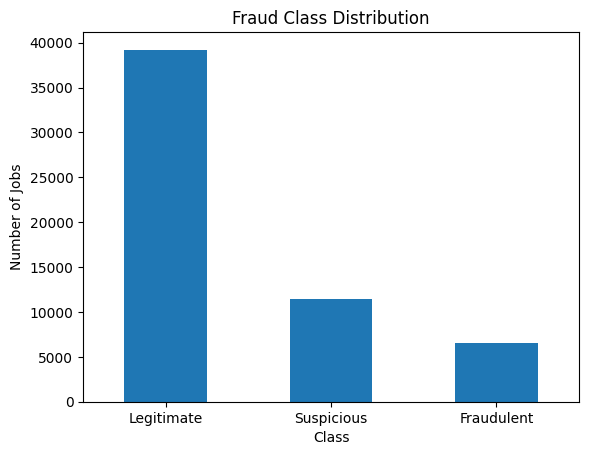

In [131]:
labeled_df = model_df[model_df['is_fraud'].notna()]

class_counts = labeled_df['is_fraud'].value_counts().sort_index()
class_counts.index = class_counts.index.map({
    0: 'Legitimate',
    1: 'Suspicious',
    2: 'Fraudulent'
})

print(class_counts)

class_counts.plot(kind='bar')
plt.title('Fraud Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

The merged dataset retains its original three-class description for data understanding. Before modelling, suspicious and fraudulent records are mapped into one fraud-risk positive class because the deployed classifier returns a binary fraud-risk probability.


### 17.3 Labeled and unlabeled records


is_fraud
Labeled      57150
Unlabeled    13152
Name: count, dtype: int64


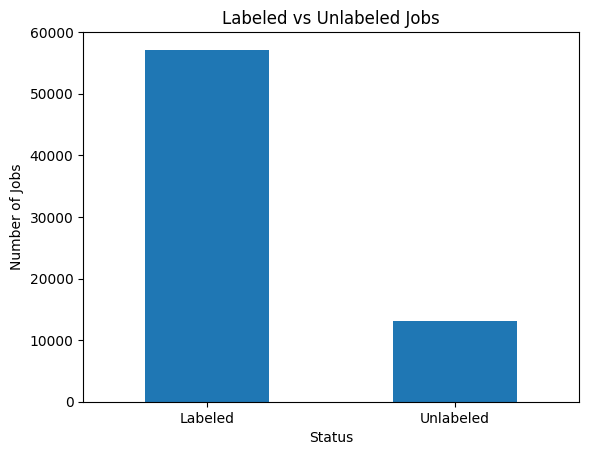

In [132]:
label_status = model_df['is_fraud'].isna().map({
    True: 'Unlabeled',
    False: 'Labeled'
}).value_counts()

print(label_status)

label_status.plot(kind='bar')
plt.title('Labeled vs Unlabeled Jobs')
plt.xlabel('Status')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

### 17.4 Fraud labels by source

This shows which sources contain labels and which are unlabeled.


In [133]:
source_labels = pd.crosstab(
    final_df['source_platform'],
    final_df['is_fraud'],
    dropna=False
)

print(source_labels)

is_fraud                     0.0    1.0   2.0   NaN
source_platform                                    
BrighterMonday Kenya           0      0     0  1954
Corporate Staffing Kenya       0      0     0  3982
Fake Job Postings Dataset  16565      0   852     0
Fuzu Kenya                     0      0     0   666
JobWeb Kenya                   0      0     0  5257
PigiaMe Kenya                  0      0     0  1293
Synthetic                  22654  11426  5653     0


### 17.5 Missing values


In [134]:
missing = model_df.isna().sum().sort_values(ascending=False)
print(missing)

salary_range         22216
min_qualification    19388
experience_level     18350
requirements         15790
is_fraud             13152
work_type            10115
company               8875
industry_category     6108
location              4539
description           1296
title                    1
dtype: int64


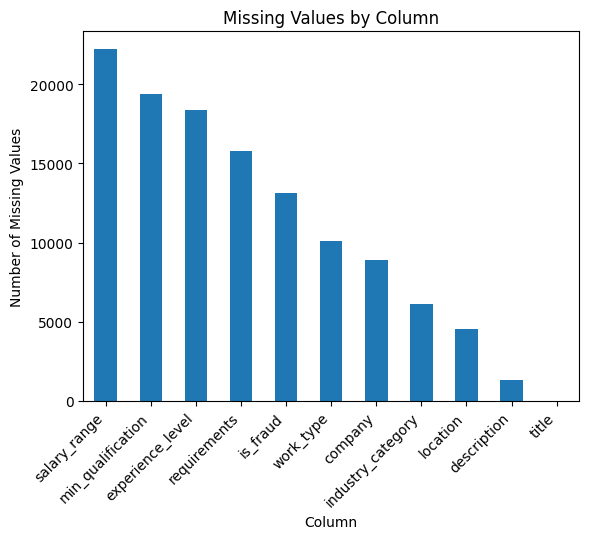

In [135]:
missing[missing > 0].plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.6 Work type


work_type
Full-time     41112
Contract      11604
Missing       10115
Full-Time      4914
Full time      1115
Part-time       754
Temporary       234
Other           223
Internship      218
Part time        10
Part-Time         3
Name: count, dtype: int64


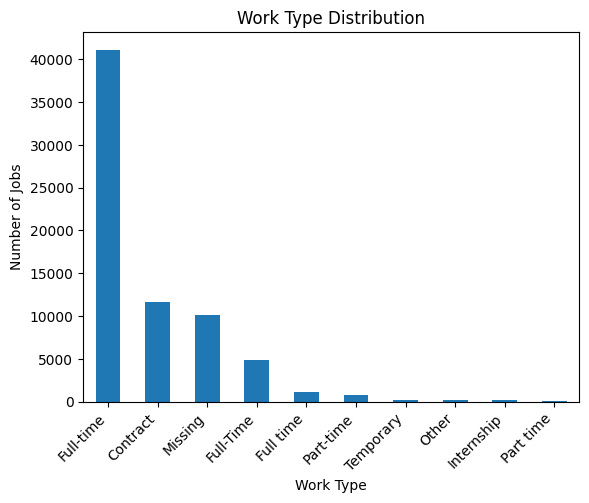

In [136]:
work_type = model_df['work_type'].fillna('Missing').value_counts()
print(work_type)

work_type.head(10).plot(kind='bar')
plt.title('Work Type Distribution')
plt.xlabel('Work Type')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.7 Experience level


experience_level
Missing                   18350
Entry level               13017
No experience required    10029
3-5 years                  9925
1-3 years                  9874
Mid-Senior level           3741
Associate                  2231
Not Applicable             1058
Mid level                   922
Director                    381
Internship                  370
Senior level                179
Executive                   138
Internship & Graduate        50
Executive level              25
No Experience                12
Name: count, dtype: int64


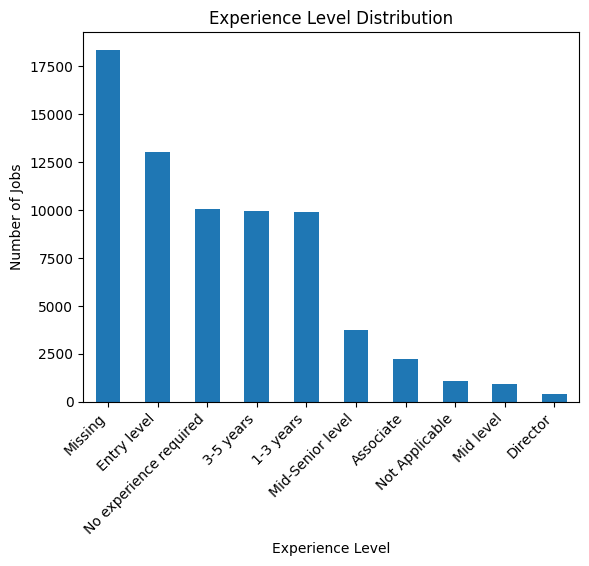

In [137]:
experience = model_df['experience_level'].fillna('Missing').value_counts()
print(experience)

experience.head(10).plot(kind='bar')
plt.title('Experience Level Distribution')
plt.xlabel('Experience Level')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.8 Industry category


industry_category
Missing                                6108
Telecommunications                     4732
Retail                                 4670
Hospitality                            4512
Construction                           4498
Manufacturing                          4474
Healthcare                             4471
Insurance                              4459
Banking & Finance                      4401
Logistics                              4397
Information Technology and Services    1693
Computer Software                      1351
Internet                               1049
Education Management                    817
Marketing and Advertising               812
Name: count, dtype: int64


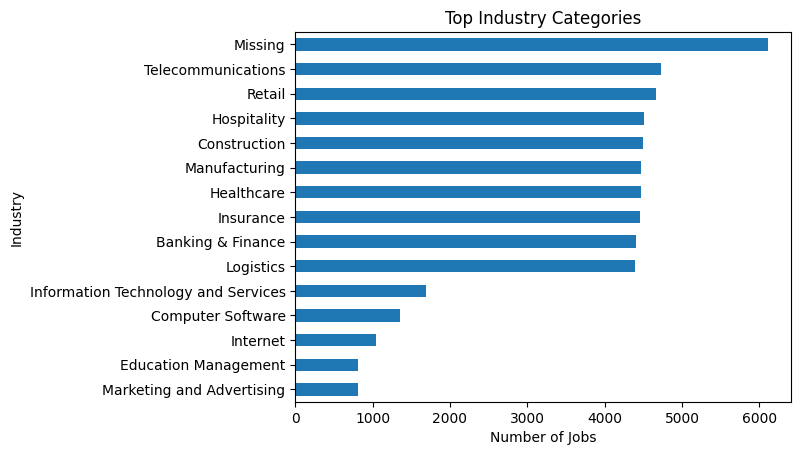

In [138]:
industry = model_df['industry_category'].fillna('Missing').value_counts()
print(industry.head(15))

industry.head(15).sort_values().plot(kind='barh')
plt.title('Top Industry Categories')
plt.xlabel('Number of Jobs')
plt.ylabel('Industry')
plt.show()

### 17.9 Text length


In [139]:
eda_df = model_df.copy()

eda_df['title_length'] = eda_df['title'].fillna('').str.len()
eda_df['description_length'] = eda_df['description'].fillna('').str.len()
eda_df['requirements_length'] = eda_df['requirements'].fillna('').str.len()

print(eda_df[['title_length', 'description_length', 'requirements_length']].describe())

       title_length  description_length  requirements_length
count  70302.000000        70302.000000         70302.000000
mean      24.905081          956.497909           172.502461
std       16.784408         1839.873628           389.247302
min        0.000000            0.000000             0.000000
25%       15.000000          243.000000            38.000000
50%       19.000000          283.000000            47.000000
75%       28.000000         1079.000000            60.000000
max      200.000000       120873.000000         10864.000000


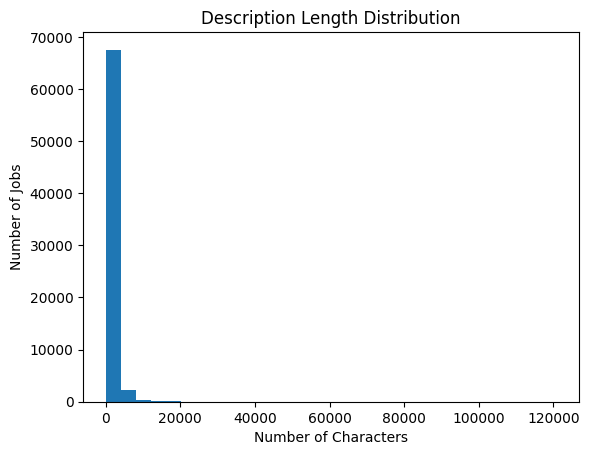

In [140]:
eda_df['description_length'].plot(kind='hist', bins=30)
plt.title('Description Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Jobs')
plt.show()

### 17.10 Description length by fraud class


is_fraud
Legitimate    664.495653
Suspicious    260.909942
Fraudulent    302.577863
Name: description_length, dtype: float64


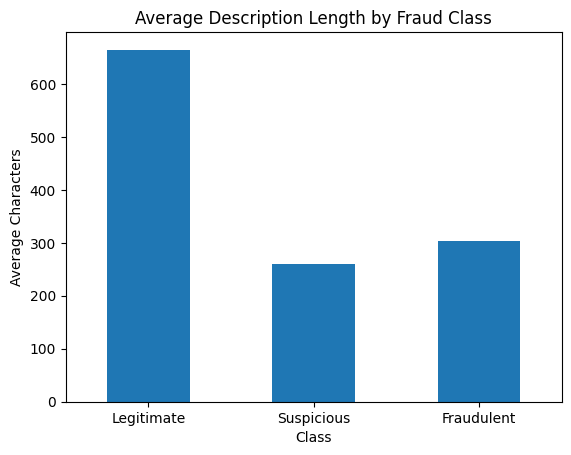

In [141]:
text_by_class = eda_df[eda_df['is_fraud'].notna()]

mean_length = text_by_class.groupby('is_fraud')['description_length'].mean()
mean_length.index = mean_length.index.map({
    0: 'Legitimate',
    1: 'Suspicious',
    2: 'Fraudulent'
})

print(mean_length)

mean_length.plot(kind='bar')
plt.title('Average Description Length by Fraud Class')
plt.xlabel('Class')
plt.ylabel('Average Characters')
plt.xticks(rotation=0)
plt.show()

### 17.11 Salary in the cleaned synthetic 40K data


In [142]:
if 'salary_amount' not in df1.columns:
    print("salary_amount missing — re-parsing salary_range first.")
    salary_pattern = re.compile(r'^(KES|USD)\s*([\d,]+)\s*/\s*(\w+)$', flags=re.IGNORECASE)

    def parse_salary(value):
        if pd.isna(value):
            return pd.Series([np.nan, np.nan, np.nan])
        m = salary_pattern.match(str(value).strip())
        if not m:
            return pd.Series([np.nan, np.nan, np.nan])
        currency, amount, period = m.groups()
        return pd.Series([currency.upper(), float(amount.replace(',', '')), period.lower()])

    df1[['salary_currency', 'salary_amount', 'salary_period']] = df1['salary_range'].apply(parse_salary)

# Convert every salary to a single KES figure so USD and KES postings
# are comparable on one axis.
df1['salary_amount_kes'] = df1['salary_amount']
is_usd = df1['salary_currency'] == 'USD'
df1.loc[is_usd, 'salary_amount_kes'] = df1.loc[is_usd, 'salary_amount'] * USD_TO_KES

print('Converted USD rows:', int(is_usd.sum()))
print(df1[['salary_currency', 'salary_amount', 'salary_amount_kes']].dropna().head())

salary_amount missing — re-parsing salary_range first.
Converted USD rows: 13987
  salary_currency  salary_amount  salary_amount_kes
0             KES       339000.0           339000.0
1             KES        35000.0            35000.0
2             KES        38000.0            38000.0
3             USD          829.0           107770.0
4             KES        83000.0            83000.0


In [143]:
salary = df1[df1['salary_amount_kes'].notna()]

print('Salary records:', len(salary))
print(salary['salary_amount_kes'].describe())

Salary records: 40000
count     40000.000000
mean     116119.520500
std      111917.522057
min       30000.000000
25%       58000.000000
50%       78000.000000
75%      104650.000000
max      584870.000000
Name: salary_amount_kes, dtype: float64


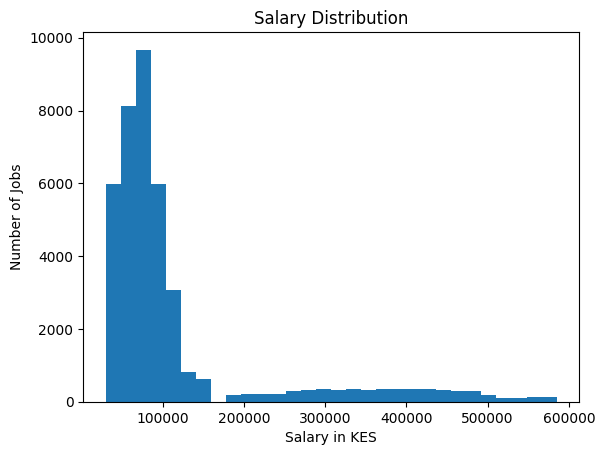

In [144]:
salary['salary_amount_kes'].plot(kind='hist', bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary in KES')
plt.ylabel('Number of Jobs')
plt.show()

### 17.12 Salary by fraud class


is_fraud
Legitimate     68522.849893
Suspicious     85728.769796
Fraudulent    367301.352818
Name: salary_amount_kes, dtype: float64


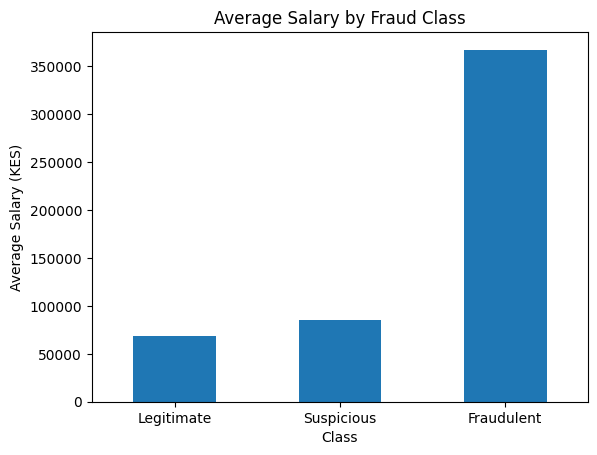

In [145]:
salary_by_class = salary.groupby('is_fraud')['salary_amount_kes'].mean()
salary_by_class.index = salary_by_class.index.map({
    0: 'Legitimate',
    1: 'Suspicious',
    2: 'Fraudulent'
})

print(salary_by_class)

salary_by_class.plot(kind='bar')
plt.title('Average Salary by Fraud Class')
plt.xlabel('Class')
plt.ylabel('Average Salary (KES)')
plt.xticks(rotation=0)
plt.show()

### 17.13 Quick check of the augmentation dataset


Rows: 4990

Fraud classes:
is_fraud
0    4258
1     525
2     207
Name: count, dtype: Int64

Email status:
has_email
Email provided    4258
Email missing      732
Name: count, dtype: int64


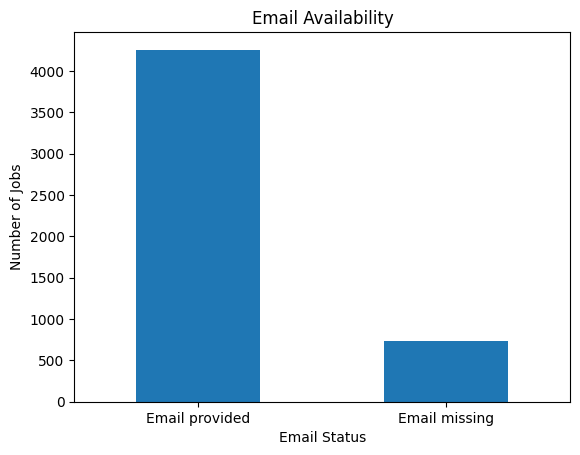

In [146]:
print('Rows:', len(df2))

print('\nFraud classes:')
print(df2['is_fraud'].value_counts().sort_index())

print('\nEmail status:')
email = df2['has_email'].map({True: 'Email provided', False: 'Email missing'}).value_counts()
print(email)

email.plot(kind='bar')
plt.title('Email Availability')
plt.xlabel('Email Status')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

### 17.14 Final EDA summary


In [147]:
print('EDA complete')
print('Rows:', len(model_df))
print('Columns:', len(model_df.columns))
print('Labeled:', model_df['is_fraud'].notna().sum())
print('Unlabeled:', model_df['is_fraud'].isna().sum())
print('Duplicate rows:', model_df.duplicated().sum())

EDA complete
Rows: 70302
Columns: 11
Labeled: 57150
Unlabeled: 13152
Duplicate rows: 0


# Modelling

1. Define Target
2. Carve Out Real-Only Holdout
3. Build Model Data
4. Train / Validation / Test Split
5. NLP Text Preprocessing
6. Text Feature Engineering
7. Structured Feature Engineering
8. Baseline Models
9. Class Imbalance Handling
10. Hybrid NLP Model
11. Model Comparison
12. Hyperparameter Tuning
13. Probability Analysis
14. Final Evaluation
15. Error Analysis
16. Model Interpretability
17. Select Final Model
18. Save Model Pipeline
19. Real Holdout Validation
20. Modelling Report


In [148]:
# Modelling dataset
nlp_df = model_df.copy()

The modelling flow moves from a text-only baseline to a hybrid model combining raw text and numeric signals. Logistic Regression and LinearSVC are trained, tuned, and evaluated with validation data before the single final holdout evaluation.


## Define Target


In [149]:
# Define Target
target = "is_fraud"

binary_target = "is_fraud_binary"

binary_map = {0: 0,1: 1, 2: 1}

class_names = {0: "Legitimate", 1: "Fraud-risk"}

In [150]:
# Create the binary target
nlp_df[binary_target] = nlp_df[target].map(binary_map)

# Verify the mapping
pd.crosstab(nlp_df['is_fraud'], nlp_df['is_fraud_binary'], dropna=False)

is_fraud_binary,0.0,1.0,NaN
is_fraud,,,
0.0,39219,0,0
1.0,0,11426,0
2.0,0,6505,0
NaN,0,0,13152


## CARVE OUT REAL-ONLY HOLDOUT

EMSCAD gives you genuine labels, whereas your synthetic dataset was generated. So don't randomly mix everything and report only one test-set score. The model can potentially learn characteristics of your synthetic generator and appear much better than it really is.


In [151]:
import hashlib

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Corrected split cell.
# Only REAL labelled data (EMSCAD) is validated or held out; synthetic
# rows are added to training only. Splitting is done by FINGERPRINT
# GROUP, not by row, so near-duplicate postings can never end up on
# both sides of a split.

# Defensive guard 1: final_df must carry is_fraud_binary. If it doesn't
# (e.g. final_df was reloaded/reassigned after that cell last ran),
# recreate it here rather than fail deep inside a later filter.
if "is_fraud_binary" not in final_df.columns:
    print("final_df was missing is_fraud_binary -- recreating it.")
    final_df["is_fraud_binary"] = final_df["is_fraud"].map({0: 0, 1: 1, 2: 1})

# Defensive guard 2: real_labelled must be a DataFrame with the text
# columns this cell needs. If an earlier cell reassigned it to a Series
# (e.g. real_labelled = real_labelled["is_fraud_binary"] or the result
# of a .value_counts() call), rebuild it from final_df instead of
# failing on a KeyError deep inside fingerprint_frame.
REQUIRED_COLUMNS = {"title", "description", "requirements", "is_fraud_binary"}
if not isinstance(real_labelled, pd.DataFrame) or not REQUIRED_COLUMNS.issubset(real_labelled.columns):
    print("real_labelled was not a valid DataFrame -- rebuilding from final_df.")
    real_labelled = final_df[
        (final_df["source_platform"] == "Fake Job Postings Dataset")
        & (final_df["is_fraud_binary"].notna())
    ].copy()

def fingerprint_frame(frame, text_columns=("title", "description", "requirements")):
    normalized = (
        frame[list(text_columns)]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.lower()
        .str.replace(r"[^a-z0-9\s]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return normalized.map(
        lambda text: hashlib.md5(text.encode("utf-8")).hexdigest() if text else None
    )

# 1. Fingerprint the real labelled pool. Target stays as is_fraud_binary.
real_labelled = real_labelled.copy()
real_labelled["fingerprint"] = fingerprint_frame(real_labelled)

# 2. Drop fingerprint groups whose real labels disagree with each other --
#    the label is ambiguous for these, so they can't be trusted either way.
label_counts = (
    real_labelled.dropna(subset=["fingerprint"])
    .groupby("fingerprint")["is_fraud_binary"]
    .nunique()
)
conflicting_fp = set(label_counts[label_counts > 1].index)
print("Conflicting-label fingerprint groups dropped:", len(conflicting_fp))
real_labelled = real_labelled[~real_labelled["fingerprint"].isin(conflicting_fp)].copy()

# 3. Build a ONE-ROW-PER-FINGERPRINT table to split on, so the split
#    decision is made at the group level. Rows without text (no
#    fingerprint) are treated as their own singleton groups.
real_labelled["_group_id"] = real_labelled["fingerprint"].fillna(
    pd.Series("row_" + real_labelled.index.astype(str), index=real_labelled.index)
)
groups = (
    real_labelled.groupby("_group_id")["is_fraud_binary"]
    .first()
    .reset_index()
)

# 4. Stratified split at the GROUP level: 70% train / 15% validation / 15% holdout.
train_groups, temp_groups = train_test_split(
    groups,
    test_size=0.30,
    stratify=groups["is_fraud_binary"],
    random_state=42,
)
validation_groups, holdout_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    stratify=temp_groups["is_fraud_binary"],
    random_state=42,
)

# 5. Map every row back to its group's split -- all rows sharing a
#    fingerprint land in the same partition.
train_ids = set(train_groups["_group_id"])
validation_ids = set(validation_groups["_group_id"])
holdout_ids = set(holdout_groups["_group_id"])

real_train_df = real_labelled[real_labelled["_group_id"].isin(train_ids)].drop(columns="_group_id")
real_validation_df = real_labelled[real_labelled["_group_id"].isin(validation_ids)].drop(columns="_group_id")
real_holdout = real_labelled[real_labelled["_group_id"].isin(holdout_ids)].drop(columns="_group_id")

# 6. Synthetic rows: training only, never validation or holdout.
synthetic_training_df = final_df[
    (final_df["data_source"] == "synthetic") & final_df["is_fraud_binary"].notna()
].copy()
synthetic_training_df["fingerprint"] = fingerprint_frame(synthetic_training_df)

# 7. Combine real + synthetic training rows into the training pool.
training_pool = pd.concat([real_train_df, synthetic_training_df], ignore_index=True)

# 8. Guarantee fingerprint isolation.
train_fp = set(training_pool["fingerprint"].dropna())
val_fp = set(real_validation_df["fingerprint"].dropna())
holdout_fp = set(real_holdout["fingerprint"].dropna())

assert not train_fp & val_fp, "Training/validation fingerprint overlap detected"
assert not train_fp & holdout_fp, "Training/holdout fingerprint overlap detected"
assert not val_fp & holdout_fp, "Validation/holdout fingerprint overlap detected"

# 9. Alias so downstream cells that expect fraud_risk still work,
#    without renaming is_fraud_binary itself.
for frame in (training_pool, real_validation_df, real_holdout):
    frame["fraud_risk"] = frame["is_fraud_binary"]

print("real_train_df:", real_train_df.shape)
print("synthetic_training_df:", synthetic_training_df.shape)
print("training_pool:", training_pool.shape)
print("real_validation_df:", real_validation_df.shape)
print("real_holdout:", real_holdout.shape)
print("Fingerprint isolation confirmed.")

final_df was missing is_fraud_binary -- recreating it.
real_labelled was not a valid DataFrame -- rebuilding from final_df.
Conflicting-label fingerprint groups dropped: 0
real_train_df: (12266, 16)
synthetic_training_df: (39733, 16)
training_pool: (51999, 17)
real_validation_df: (2621, 17)
real_holdout: (2530, 17)
Fingerprint isolation confirmed.


It takes the real, EMSCAD-labelled job postings and splits them into three separate partitions — training, validation, and holdout — by first fingerprinting each posting's text (title, description, requirements), then splitting at the fingerprint-group level rather than the row level so that near-duplicate postings always stay together in the same partition. It drops any fingerprint groups whose real labels contradict each other, adds synthetic postings to the training partition only, and finishes with three assertions that verify no posting fingerprint appears in more than one partition.

In [152]:
# Separate labelled and unalabelled data
# Labelled data for modelling
labelled_df = nlp_df[
    nlp_df["is_fraud_binary"].notna()
].copy()

# Unlabelled Kenya job postings for later prediction
unlabelled_df = nlp_df[
    nlp_df["is_fraud_binary"].isna()
].copy()

print("Labelled data:", labelled_df.shape)
print("Unlabelled data:", unlabelled_df.shape)

Labelled data: (57150, 12)
Unlabelled data: (13152, 12)


In [153]:
def _has_combined_text(name):
    return name in globals() and isinstance(globals()[name], pd.DataFrame) and "combined_text" in globals()[name].columns

if not (_has_combined_text("model_train") and _has_combined_text("model_validation") and _has_combined_text("model_holdout")):
    print("model_train/model_validation/model_holdout missing or incomplete -- rebuilding.")

    REQUIRED = {"training_pool", "real_validation_df", "real_holdout"}
    missing = [name for name in REQUIRED if name not in globals()]
    if missing:
        raise NameError(
            f"Cannot rebuild model_train/model_validation/model_holdout -- "
            f"{missing} are also missing. Run the fingerprint-split cell first."
        )

    model_train = training_pool.copy()
    model_validation = real_validation_df.copy()
    model_holdout = real_holdout.copy()

    TEXT_COLUMNS = ["title", "description", "requirements"]

    def build_model_text(df):
        available_columns = [c for c in TEXT_COLUMNS if c in df.columns]
        return (
            df[available_columns]
            .fillna("")
            .astype(str)
            .agg(" ".join, axis=1)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

    model_train["combined_text"] = build_model_text(model_train)
    model_validation["combined_text"] = build_model_text(model_validation)
    model_holdout["combined_text"] = build_model_text(model_holdout)

    print("model_train:", model_train.shape)
    print("model_validation:", model_validation.shape)
    print("model_holdout:", model_holdout.shape)

# Extract raw text and labels for modelling.

X_train_text = model_train["combined_text"]
X_validation_text = model_validation["combined_text"]
X_holdout_text = model_holdout["combined_text"]

y_train = model_train["is_fraud_binary"].astype(int)
y_validation = model_validation["is_fraud_binary"].astype(int)
y_holdout = model_holdout["is_fraud_binary"].astype(int)

# Basic input checks.
assert X_train_text.str.len().gt(0).all(), "Empty text found in training set"
assert X_validation_text.str.len().gt(0).all(), "Empty text found in validation set"
assert X_holdout_text.str.len().gt(0).all(), "Empty text found in holdout set"

print("X_train_text:", X_train_text.shape)
print("X_validation_text:", X_validation_text.shape)
print("X_holdout_text:", X_holdout_text.shape)
print()
print("Training labels:")
print(y_train.value_counts().sort_index())
print()
print("Real validation labels:")
print(y_validation.value_counts().sort_index())
print()
print("Real holdout labels:")
print(y_holdout.value_counts().sort_index())

X_train_text: (51999,)
X_validation_text: (2621,)
X_holdout_text: (2530,)

Training labels:
is_fraud_binary
0    34318
1    17681
Name: count, dtype: int64

Real validation labels:
is_fraud_binary
0    2494
1     127
Name: count, dtype: int64

Real holdout labels:
is_fraud_binary
0    2407
1     123
Name: count, dtype: int64


In [154]:
# Extract raw text and labels for modelling.

X_train_text = model_train["combined_text"]
X_validation_text = model_validation["combined_text"]
X_holdout_text = model_holdout["combined_text"]

y_train = model_train["is_fraud_binary"].astype(int)
y_validation = model_validation["is_fraud_binary"].astype(int)
y_holdout = model_holdout["is_fraud_binary"].astype(int)

# Basic input checks.
assert X_train_text.str.len().gt(0).all(), "Empty text found in training set"
assert X_validation_text.str.len().gt(0).all(), "Empty text found in validation set"
assert X_holdout_text.str.len().gt(0).all(), "Empty text found in holdout set"

print("X_train_text:", X_train_text.shape)
print("X_validation_text:", X_validation_text.shape)
print("X_holdout_text:", X_holdout_text.shape)
print()
print("Training labels:")
print(y_train.value_counts().sort_index())
print()
print("Real validation labels:")
print(y_validation.value_counts().sort_index())
print()
print("Real holdout labels:")
print(y_holdout.value_counts().sort_index())

X_train_text: (51999,)
X_validation_text: (2621,)
X_holdout_text: (2530,)

Training labels:
is_fraud_binary
0    34318
1    17681
Name: count, dtype: int64

Real validation labels:
is_fraud_binary
0    2494
1     127
Name: count, dtype: int64

Real holdout labels:
is_fraud_binary
0    2407
1     123
Name: count, dtype: int64


In [155]:
# Create binary target in final_df
# Use final_df since model_df no longer contains source_platform to only ideentify real/synthetic records
final_df["is_fraud_binary"] = final_df["is_fraud"].map({
    0: 0,   # Legitimate
    1: 1,   # Suspicious → Fraud-risk
    2: 1    # Fraudulent → Fraud-risk
})

In [156]:
# Identify labeller real-world data
real_labelled = final_df[
    (final_df["source_platform"] == "Fake Job Postings Dataset") &
    (final_df["is_fraud_binary"].notna())
].copy()

real_labelled["is_fraud_binary"].value_counts()

is_fraud_binary
0.0    16565
1.0      852
Name: count, dtype: int64

In [157]:
# The corrected split cell already created the synthetic-assisted
# training pool. Do not concatenate the synthetic rows again.

print("Training pool already prepared")
print("Real training rows:", len(real_train_df))
print("Synthetic training rows:", len(synthetic_training_df))
print("Combined training rows:", len(training_pool))
print("Real validation rows:", len(real_validation_df))
print("Untouched real holdout rows:", len(real_holdout))

print("\nTraining target distribution:")
print(
    training_pool["fraud_risk"]
    .value_counts()
    .sort_index()
)

Training pool already prepared
Real training rows: 12266
Synthetic training rows: 39733
Combined training rows: 51999
Real validation rows: 2621
Untouched real holdout rows: 2530

Training target distribution:
fraud_risk
0.0    34318
1.0    17681
Name: count, dtype: int64


In [158]:
# Compatibility aliases for the existing modelling workflow.
# The rest of the notebook should use these corrected partitions.

model_train = training_pool.copy()
model_validation = real_validation_df.copy()
model_holdout = real_holdout.copy()
TARGET_COLUMN = "fraud_risk"
print("model_train:", model_train.shape)
print("model_validation:", model_validation.shape)
print("model_holdout:", model_holdout.shape)

model_train: (51999, 17)
model_validation: (2621, 17)
model_holdout: (2530, 17)


In [159]:
TEXT_COLUMNS = [
    "title",
    "description",
    "requirements",
]

def build_model_text(df):
    """Join the text fields consistently for every partition."""

    available_columns = [
        column
        for column in TEXT_COLUMNS
        if column in df.columns
    ]

    return (
        df[available_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


model_train["combined_text"] = build_model_text(
    model_train
)

model_validation["combined_text"] = build_model_text(
    model_validation
)

model_holdout["combined_text"] = build_model_text(
    model_holdout
)


print(
    "Training text rows:",
    len(model_train["combined_text"]),
)

print(
    "Validation text rows:",
    len(model_validation["combined_text"]),
)

print(
    "Holdout text rows:",
    len(model_holdout["combined_text"]),
)

Training text rows: 51999
Validation text rows: 2621
Holdout text rows: 2530


## Clean Development Flow

Training and validation use only the fingerprint-isolated development partitions. The real holdout is not transformed or scored until the final evaluation below.


In [160]:
from pathlib import Path
import sys

# Locate the repository root whether the kernel starts in notebooks/
# or at the project root.
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(
        "Repository root could not be located. Start the notebook from the "
        "job-scam-detection repository."
    )

project_root_string = str(PROJECT_ROOT.resolve())

if project_root_string not in sys.path:
    sys.path.insert(0, project_root_string)

from src.models.feature_builder import TextFeatureBuilder

print(f"Project root: {PROJECT_ROOT.resolve()}")
print("TextFeatureBuilder imported successfully.")

Project root: C:\Users\Administrator\Documents\GROUP\capstone\job-scam-detection
TextFeatureBuilder imported successfully.


In [161]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from src.models.feature_builder import TextFeatureBuilder

assert not set(training_pool["fingerprint"]) & set(real_validation_df["fingerprint"])
assert not set(training_pool["fingerprint"]) & set(real_holdout["fingerprint"])
assert not set(real_validation_df["fingerprint"]) & set(real_holdout["fingerprint"])

print("Clean modelling checkpoint confirmed.")
print("X_train_text:", X_train_text.shape)
print("X_validation_text:", X_validation_text.shape)
print("X_holdout_text:", X_holdout_text.shape)

Clean modelling checkpoint confirmed.
X_train_text: (51999,)
X_validation_text: (2621,)
X_holdout_text: (2530,)


### Baseline Text Model

The following cells form the only modelling path used for the final model.
Training, validation and holdout partitions were isolated by normalized text
fingerprint before any vectorizer, scaler or classifier was fitted.

`class_weight='balanced'` gives the minority Fraud-risk class more influence
during fitting without changing the original class distribution or creating
synthetic copies inside the holdout.


In [162]:
tfidf_baseline = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
)

X_train_tfidf = tfidf_baseline.fit_transform(X_train_text)
X_validation_tfidf = tfidf_baseline.transform(X_validation_text)

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)
baseline_model.fit(X_train_tfidf, y_train)

baseline_validation_proba = baseline_model.predict_proba(X_validation_tfidf)[:, 1]
baseline_validation_pred = (baseline_validation_proba >= 0.5).astype(int)

print(classification_report(
    y_validation,
    baseline_validation_pred,
    target_names=["Legitimate", "Fraud-risk"],
))
print("Baseline validation ROC-AUC:", round(
    roc_auc_score(y_validation, baseline_validation_proba), 4
))
print("Baseline validation PR-AUC:", round(
    average_precision_score(y_validation, baseline_validation_proba), 4
))

              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98      2494
  Fraud-risk       0.77      0.26      0.39       127

    accuracy                           0.96      2621
   macro avg       0.87      0.63      0.68      2621
weighted avg       0.95      0.96      0.95      2621

Baseline validation ROC-AUC: 0.9053
Baseline validation PR-AUC: 0.5091


### Hybrid Feature Construction

The hybrid model adds six numeric signals calculated internally from the same raw text. No posting columns or missing-field indicators are required, so the training interface matches the deployed `TextFeatureBuilder` interface.


In [163]:
numeric_builder = TextFeatureBuilder()

tfidf_hybrid = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
)
scaler_hybrid = StandardScaler()

X_train_hybrid_text = tfidf_hybrid.fit_transform(X_train_text)
X_validation_hybrid_text = tfidf_hybrid.transform(X_validation_text)

X_train_hybrid_numeric = scaler_hybrid.fit_transform(
    numeric_builder._numeric_features(X_train_text)
)
X_validation_hybrid_numeric = scaler_hybrid.transform(
    numeric_builder._numeric_features(X_validation_text)
)

X_train_hybrid = hstack([
    X_train_hybrid_text,
    X_train_hybrid_numeric,
]).tocsr()
X_validation_hybrid = hstack([
    X_validation_hybrid_text,
    X_validation_hybrid_numeric,
]).tocsr()

print("Hybrid training matrix:", X_train_hybrid.shape)
print("Hybrid validation matrix:", X_validation_hybrid.shape)

Hybrid training matrix: (51999, 50006)
Hybrid validation matrix: (2621, 50006)


In [164]:
hybrid_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)
hybrid_lr.fit(X_train_hybrid, y_train)

hybrid_svm = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=3000,
)
hybrid_svm.fit(X_train_hybrid, y_train)

hybrid_lr_validation_proba = hybrid_lr.predict_proba(
    X_validation_hybrid
)[:, 1]
hybrid_svm_validation_score = hybrid_svm.decision_function(
    X_validation_hybrid
)

print("Hybrid Logistic Regression validation PR-AUC:", round(
    average_precision_score(y_validation, hybrid_lr_validation_proba), 4
))
print("Hybrid LinearSVC validation PR-AUC:", round(
    average_precision_score(y_validation, hybrid_svm_validation_score), 4
))

Hybrid Logistic Regression validation PR-AUC: 0.5614
Hybrid LinearSVC validation PR-AUC: 0.714


### Model Comparison

The comparison table uses validation data only. LinearSVC is compared with decision scores, not probabilities. Logistic Regression is the deployment candidate because it provides probabilities for thresholding and risk ranking, while remaining interpretable and compatible with sparse text.


In [165]:
model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF Logistic Regression",
        "Hybrid Logistic Regression",
        "Hybrid LinearSVC",
    ],
    "Accuracy": [
        accuracy_score(y_validation, baseline_validation_pred),
        accuracy_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        accuracy_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "Precision": [
        precision_score(y_validation, baseline_validation_pred),
        precision_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        precision_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "Recall": [
        recall_score(y_validation, baseline_validation_pred),
        recall_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        recall_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "F1": [
        f1_score(y_validation, baseline_validation_pred),
        f1_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        f1_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "ROC-AUC": [
        roc_auc_score(y_validation, baseline_validation_proba),
        roc_auc_score(y_validation, hybrid_lr_validation_proba),
        roc_auc_score(y_validation, hybrid_svm_validation_score),
    ],
    "PR-AUC": [
        average_precision_score(y_validation, baseline_validation_proba),
        average_precision_score(y_validation, hybrid_lr_validation_proba),
        average_precision_score(y_validation, hybrid_svm_validation_score),
    ],
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,TF-IDF Logistic Regression,0.9603,0.7674,0.2598,0.3882,0.9053,0.5091
1,Hybrid Logistic Regression,0.9603,0.7556,0.2677,0.3953,0.9212,0.5614
2,Hybrid LinearSVC,0.9733,0.8608,0.5354,0.6602,0.9434,0.7140


### Training-Only Hyperparameter Tuning

GridSearchCV is restricted to `X_train_hybrid` and `y_train`. It uses average precision because the fraud-risk class is less frequent, and it never sees the real validation or holdout rows.


In [166]:
svm_grid = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=42, max_iter=3000),
    {"C": [0.01, 0.1, 1, 10]},
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
svm_grid.fit(X_train_hybrid, y_train)

lr_grid = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    ),
    {"C": [0.01, 0.1, 1, 10, 100]},
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
lr_grid.fit(X_train_hybrid, y_train)

best_svm = svm_grid.best_estimator_
best_lr = lr_grid.best_estimator_
print("Best LinearSVC parameters:", svm_grid.best_params_)
print("Best Logistic Regression parameters:", lr_grid.best_params_)
print("Best Logistic Regression CV PR-AUC:", round(lr_grid.best_score_, 4))

Best LinearSVC parameters: {'C': 1}
Best Logistic Regression parameters: {'C': 10}
Best Logistic Regression CV PR-AUC: 0.987


In [167]:
from sklearn.naive_bayes import MultinomialNB

nb_grid = GridSearchCV(
    MultinomialNB(),
    {"alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
nb_grid.fit(X_train_tfidf, y_train)

best_nb = nb_grid.best_estimator_
print("Best Naive Bayes parameters:", nb_grid.best_params_)
print("Best Naive Bayes CV PR-AUC:", round(nb_grid.best_score_, 4))

Best Naive Bayes parameters: {'alpha': 0.1}
Best Naive Bayes CV PR-AUC: 0.9901


In [168]:
nb_validation_proba = best_nb.predict_proba(X_validation_tfidf)[:, 1]
nb_validation_pred = (nb_validation_proba >= 0.5).astype(int)

print(classification_report(
    y_validation,
    nb_validation_pred,
    target_names=["Legitimate", "Fraud-risk"],
))
print("Naive Bayes validation ROC-AUC:", round(
    roc_auc_score(y_validation, nb_validation_proba), 4
))
print("Naive Bayes validation PR-AUC:", round(
    average_precision_score(y_validation, nb_validation_proba), 4
))

              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98      2494
  Fraud-risk       1.00      0.13      0.22       127

    accuracy                           0.96      2621
   macro avg       0.98      0.56      0.60      2621
weighted avg       0.96      0.96      0.94      2621

Naive Bayes validation ROC-AUC: 0.8558
Naive Bayes validation PR-AUC: 0.3506


In [169]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight("balanced", y_train)

nb_grid_balanced = GridSearchCV(
    MultinomialNB(),
    {"alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
nb_grid_balanced.fit(X_train_tfidf, y_train, sample_weight=sample_weights)

best_nb_balanced = nb_grid_balanced.best_estimator_
print("Best Naive Bayes (balanced) parameters:", nb_grid_balanced.best_params_)

nb_balanced_proba = best_nb_balanced.predict_proba(X_validation_tfidf)[:, 1]
nb_balanced_pred = (nb_balanced_proba >= 0.5).astype(int)

print(classification_report(
    y_validation, nb_balanced_pred,
    target_names=["Legitimate", "Fraud-risk"],
))
print("Naive Bayes (balanced) validation ROC-AUC:", round(
    roc_auc_score(y_validation, nb_balanced_proba), 4
))
print("Naive Bayes (balanced) validation PR-AUC:", round(
    average_precision_score(y_validation, nb_balanced_proba), 4
))

Best Naive Bayes (balanced) parameters: {'alpha': 0.5}
              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98      2494
  Fraud-risk       0.92      0.09      0.17       127

    accuracy                           0.96      2621
   macro avg       0.94      0.55      0.57      2621
weighted avg       0.95      0.96      0.94      2621

Naive Bayes (balanced) validation ROC-AUC: 0.8259
Naive Bayes (balanced) validation PR-AUC: 0.3074


In [170]:
model_comparison = pd.concat([model_comparison, pd.DataFrame([{
    "Model": "TF-IDF Naive Bayes (balanced)",
    "Accuracy": accuracy_score(y_validation, nb_balanced_pred),
    "Precision": precision_score(y_validation, nb_balanced_pred),
    "Recall": recall_score(y_validation, nb_balanced_pred),
    "F1": f1_score(y_validation, nb_balanced_pred),
    "ROC-AUC": roc_auc_score(y_validation, nb_balanced_proba),
    "PR-AUC": average_precision_score(y_validation, nb_balanced_proba),
}])], ignore_index=True)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,TF-IDF Logistic Regression,0.960320,0.767442,0.259843,0.388235,0.905256,0.509137
1,Hybrid Logistic Regression,0.960320,0.755556,0.267717,0.395349,0.921194,0.561442
2,Hybrid LinearSVC,0.973293,0.860759,0.535433,0.660194,0.943385,0.714002
3,TF-IDF Naive Bayes (balanced),0.955742,0.923077,0.094488,0.171429,0.825910,0.307415


In [171]:
from sklearn.metrics import balanced_accuracy_score

model_comparison["Balanced Accuracy"] = [
    balanced_accuracy_score(y_validation, baseline_validation_pred),
    balanced_accuracy_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
    balanced_accuracy_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    balanced_accuracy_score(y_validation, nb_balanced_pred),
]

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Balanced Accuracy
0,TF-IDF Logistic Regression,0.960320,0.767442,0.259843,0.388235,0.905256,0.509137,0.627916
1,Hybrid Logistic Regression,0.960320,0.755556,0.267717,0.395349,0.921194,0.561442,0.631653
2,Hybrid LinearSVC,0.973293,0.860759,0.535433,0.660194,0.943385,0.714002,0.765511
3,TF-IDF Naive Bayes (balanced),0.955742,0.923077,0.094488,0.171429,0.825910,0.307415,0.547044


In [172]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_svm = CalibratedClassifierCV(
    LinearSVC(C=best_svm.C, class_weight="balanced", random_state=42, max_iter=3000),
    method="sigmoid",
    cv=5,
)
calibrated_svm.fit(X_train_hybrid, y_train)

calibrated_svm_proba = calibrated_svm.predict_proba(X_validation_hybrid)[:, 1]
calibrated_svm_pred = (calibrated_svm_proba >= 0.5).astype(int)

print(classification_report(
    y_validation,
    calibrated_svm_pred,
    target_names=["Legitimate", "Fraud-risk"],
))
print("Calibrated SVM validation ROC-AUC:", round(
    roc_auc_score(y_validation, calibrated_svm_proba), 4
))
print("Calibrated SVM validation PR-AUC:", round(
    average_precision_score(y_validation, calibrated_svm_proba), 4
))
print("Calibrated SVM balanced accuracy:", round(
    balanced_accuracy_score(y_validation, calibrated_svm_pred), 4
))


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.98      2494
  Fraud-risk       0.90      0.43      0.58       127

    accuracy                           0.97      2621
   macro avg       0.94      0.71      0.78      2621
weighted avg       0.97      0.97      0.96      2621

Calibrated SVM validation ROC-AUC: 0.879
Calibrated SVM validation PR-AUC: 0.6527
Calibrated SVM balanced accuracy: 0.7114


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [173]:
calibrated_svm_threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    predictions = (calibrated_svm_proba >= threshold).astype(int)
    matrix = confusion_matrix(y_validation, predictions)
    calibrated_svm_threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "F1": f1_score(y_validation, predictions, zero_division=0),
        "false_positives": int(matrix[0, 1]),
        "false_negatives": int(matrix[1, 0]),
    })

calibrated_svm_threshold_table = pd.DataFrame(calibrated_svm_threshold_rows)
best_svm_threshold = float(
    calibrated_svm_threshold_table.loc[
        calibrated_svm_threshold_table["F1"].idxmax(), "threshold"
    ]
)

print("Calibrated SVM threshold table:")
print(calibrated_svm_threshold_table)
print("\nSelected SVM threshold:", best_svm_threshold)

Calibrated SVM threshold table:
    threshold  precision    recall        F1  false_positives  false_negatives
0        0.10   0.715686  0.574803  0.637555               29               54
1        0.15   0.795455  0.551181  0.651163               18               57
2        0.20   0.811765  0.543307  0.650943               16               58
3        0.25   0.829268  0.535433  0.650718               14               59
4        0.30   0.858974  0.527559  0.653659               11               60
5        0.35   0.865672  0.456693  0.597938                9               69
6        0.40   0.878788  0.456693  0.601036                8               69
7        0.45   0.888889  0.440945  0.589474                7               71
8        0.50   0.900000  0.425197  0.577540                6               73
9        0.55   0.898305  0.417323  0.569892                6               74
10       0.60   0.882353  0.354331  0.505618                6               82
11       0.65   0.90

### Validation Threshold Selection

The threshold sweep changes the probability cutoff and records precision, recall, F1, false positives, and false negatives on real validation data. The default 0.5 is not automatically accepted because missing fraud is more harmful than an understandable increase in review alerts.


In [174]:
# The full sweep (calibrated_svm_threshold_table) was already computed above.
# 0.10 is chosen deliberately over the max-F1 threshold: missing a real scam
# is worse than an extra caution flag on a legitimate posting, so recall is
# prioritized over the precision/recall balance F1 would pick automatically.
best_threshold = 0.10

print("Validation threshold table:")
display(calibrated_svm_threshold_table.round(4))
print("Selected validation threshold:", best_threshold)


Validation threshold table:


,threshold,precision,recall,F1,false_positives,false_negatives
0,0.10,0.7157,0.5748,0.6376,29,54
1,0.15,0.7955,0.5512,0.6512,18,57
2,0.20,0.8118,0.5433,0.6509,16,58
3,0.25,0.8293,0.5354,0.6507,14,59
4,0.30,0.8590,0.5276,0.6537,11,60
5,0.35,0.8657,0.4567,0.5979,9,69
6,0.40,0.8788,0.4567,0.6010,8,69
7,0.45,0.8889,0.4409,0.5895,7,71
8,0.50,0.9000,0.4252,0.5775,6,73
9,0.55,0.8983,0.4173,0.5699,6,74


Selected validation threshold: 0.1


### Final Development Fit

After model and threshold selection, the final calibrated LinearSVC
(`CalibratedClassifierCV`, sigmoid method, using the tuned `C` from
`svm_grid`) is refit on the combined training and validation development
data. The holdout remains untouched, and the final TF-IDF vocabulary and
scaler are fitted only on this development data.


In [175]:
X_development_text = pd.concat(
    [X_train_text, X_validation_text],
    ignore_index=True,
)
y_development = pd.concat(
    [y_train, y_validation],
    ignore_index=True,
)

final_tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
)
final_scaler = StandardScaler()
final_builder = TextFeatureBuilder()

X_development_text_features = final_tfidf.fit_transform(X_development_text)
X_development_numeric = final_scaler.fit_transform(
    final_builder._numeric_features(X_development_text)
)
X_development_hybrid = hstack([
    X_development_text_features,
    X_development_numeric,
]).tocsr()

final_model = CalibratedClassifierCV(
    LinearSVC(
        C=best_svm.C,
        class_weight="balanced",
        random_state=42,
        max_iter=3000,
    ),
    method="sigmoid",
    cv=5,
)
final_model.fit(X_development_hybrid, y_development)
final_threshold = best_threshold

print("Final development rows:", len(X_development_text))
print("Final threshold:", final_threshold)


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Final development rows: 54620
Final threshold: 0.1


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Final Evaluation

The real holdout is transformed and scored for the first time here. This primary evaluation reports the unbiased performance of the final model selected from training and validation.


In [176]:
X_holdout_text_features = final_tfidf.transform(X_holdout_text)
X_holdout_numeric_final = final_scaler.transform(
    final_builder._numeric_features(X_holdout_text)
)
X_holdout_final = hstack([
    X_holdout_text_features,
    X_holdout_numeric_final,
]).tocsr()

final_holdout_proba = final_model.predict_proba(X_holdout_final)[:, 1]
final_holdout_pred = (final_holdout_proba >= final_threshold).astype(int)

final_report = classification_report(
    y_holdout,
    final_holdout_pred,
    target_names=["Legitimate", "Fraud-risk"],
    output_dict=True,
)
final_matrix = confusion_matrix(y_holdout, final_holdout_pred)
tn, fp, fn, tp = final_matrix.ravel()

print(classification_report(
    y_holdout,
    final_holdout_pred,
    target_names=["Legitimate", "Fraud-risk"],
))
print("Final holdout ROC-AUC:", round(
    roc_auc_score(y_holdout, final_holdout_proba), 4
))
print("Final holdout PR-AUC:", round(
    average_precision_score(y_holdout, final_holdout_proba), 4
))
print("Confusion matrix:")
print(final_matrix)
print({
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
})

              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      2407
  Fraud-risk       0.72      0.78      0.75       123

    accuracy                           0.97      2530
   macro avg       0.86      0.88      0.87      2530
weighted avg       0.98      0.97      0.98      2530

Final holdout ROC-AUC: 0.9571
Final holdout PR-AUC: 0.8155
Confusion matrix:
[[2370   37]
 [  27   96]]
{'true_negatives': 2370, 'false_positives': 37, 'false_negatives': 27, 'true_positives': 96}


### Interpreting the Final Confusion Matrix

The confusion matrix reports how the tool behaves for a job seeker: true negatives are legitimate postings left unflagged, false positives are legitimate postings incorrectly warned about, false negatives are fraudulent postings missed, and true positives are fraudulent postings detected. False negatives matter most because a missed scam can lead to financial loss or stolen personal information. The real holdout result is more trustworthy than synthetic-heavy validation because it measures performance on unseen real EMSCAD postings.


### Post Hoc Holdout Threshold Diagnostic

Post hoc diagnostic only. These results were not used for model selection, training, tuning, or threshold selection. The sweep shows what recall would be achievable at lower thresholds and the precision cost on the final holdout. It is informative for future operating-point decisions, but it does not change the exported model.


In [177]:
posthoc_threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.40, final_threshold, 0.50, 0.60, 0.70]:
    predictions = (final_holdout_proba >= threshold).astype(int)
    matrix = confusion_matrix(y_holdout, predictions)
    posthoc_threshold_rows.append({
        "threshold": round(float(threshold), 3),
        "precision": precision_score(y_holdout, predictions, zero_division=0),
        "recall": recall_score(y_holdout, predictions, zero_division=0),
        "F1": f1_score(y_holdout, predictions, zero_division=0),
        "false_positives": int(matrix[0, 1]),
        "false_negatives": int(matrix[1, 0]),
    })

posthoc_threshold_table = pd.DataFrame(posthoc_threshold_rows)
display(posthoc_threshold_table.round(4))

,threshold,precision,recall,F1,false_positives,false_negatives
0,0.1,0.7218,0.7805,0.7500,37,27
1,0.2,0.8515,0.6992,0.7679,15,37
2,0.3,0.8764,0.6341,0.7358,11,45
3,0.4,0.9059,0.6260,0.7404,8,46
4,0.1,0.7218,0.7805,0.7500,37,27
5,0.5,0.9367,0.6016,0.7327,5,49
6,0.6,0.9710,0.5447,0.6979,2,56
7,0.7,0.9841,0.5041,0.6667,1,61


### Coefficient Interpretation

Positive coefficients push a posting toward Fraud-risk, negative
coefficients push it toward Legitimate. Because the final model is a
`CalibratedClassifierCV`-wrapped `LinearSVC` (`cv=5`), there is no single
coefficient vector the way plain Logistic Regression has one — the values
below are averaged across the 5 internally fitted LinearSVC folds, giving
an approximate view of feature importance rather than an exact one. Terms
such as `group looking`, `needed`, `weather`, or `shared confirm` may be
synthetic generator fragments rather than validated real-world scam
language. The deterministic API rules provide the actionable signals, such
as upfront fees, mobile money requests, passport retention, and no
interview.


In [178]:
tfidf_feature_names = final_tfidf.get_feature_names_out()
all_feature_names = list(tfidf_feature_names) + list(
    TextFeatureBuilder.NUMERIC_COLUMNS
)

# CalibratedClassifierCV(cv=5) fits 5 separate LinearSVC instances internally
# (one per fold) rather than a single one, so there is no single `.coef_`.
# Averaging across folds gives an approximate, aggregate view of feature
# importance for the calibrated SVM.
fold_coefs = np.array([
    calibrated_classifier.estimator.coef_[0]
    for calibrated_classifier in final_model.calibrated_classifiers_
])
mean_coefs = fold_coefs.mean(axis=0)

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": mean_coefs,
})

top_fraud_features = coef_df.sort_values(
    "coefficient", ascending=False
).head(20)

top_fraud_features


,feature,coefficient
47286,using link,2.006589
19157,group looking,1.763627
2909,apply using,1.743532
29814,offshore,1.369859
19149,group,1.326133
28762,needed,1.316808
31440,pay,1.284022
24809,line requirements,1.272009
10623,data entry,1.253229
48707,work,1.241970


### Pipeline Export

The exported artifact is one sklearn Pipeline containing the fitted
raw-text feature transformer, its TF-IDF vectorizer and scaler, and the
final calibrated LinearSVC classifier (`CalibratedClassifierCV`, sigmoid
calibration). It accepts a single raw text string, so the API does not
need to reconstruct structured columns.


In [179]:
from pathlib import Path
import joblib
from sklearn.pipeline import Pipeline

pipeline_feature_builder = TextFeatureBuilder()
pipeline_feature_builder.tfidf_ = final_tfidf
pipeline_feature_builder.scaler_ = final_scaler

inference_pipeline = Pipeline([
    ("features", pipeline_feature_builder),
    ("classifier", final_model),
])
inference_pipeline.version_ = "svm-hybrid-v1-calibrated"

scam_text = (
    "Immediate job opportunity. Send a mobile money registration fee today "
    "to secure your position. No interview required."
)
legitimate_text = (
    "Permanent analyst role with a written contract, formal interview, "
    "published company address, and standard employment benefits."
)

scam_score = inference_pipeline.predict_proba([scam_text])[:, 1][0]
legitimate_score = inference_pipeline.predict_proba([legitimate_text])[:, 1][0]

assert 0 <= scam_score <= 1
assert 0 <= legitimate_score <= 1
assert scam_score > legitimate_score

artifact_path = PROJECT_ROOT / "artifacts" / "model.pkl"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(inference_pipeline, artifact_path)

reloaded_pipeline = joblib.load(artifact_path)
reloaded_scores = reloaded_pipeline.predict_proba([
    scam_text,
    legitimate_text,
])[:, 1]

assert abs(reloaded_scores[0] - scam_score) < 1e-12
assert abs(reloaded_scores[1] - legitimate_score) < 1e-12

print("Pipeline version:", inference_pipeline.version_)
print("Scam-style score:", round(scam_score, 6))
print("Legitimate-style score:", round(legitimate_score, 6))
print("Saved and reloaded:", artifact_path)

Pipeline version: svm-hybrid-v1-calibrated
Scam-style score: 0.775818
Legitimate-style score: 0.048415
Saved and reloaded: c:\Users\Administrator\Documents\GROUP\capstone\job-scam-detection\artifacts\model.pkl


## 18. Modelling Report

### Corrected Data Flow

Real (EMSCAD) labelled postings are fingerprinted and split by **fingerprint group**, not by row, into `real_train_df`, `real_validation_df`, and `real_holdout` (70% / 15% / 15%, stratified on `is_fraud_binary`). Splitting by group guarantees that near-duplicate postings can never be separated across partitions. Synthetic postings (`synthetic_training_df`) are added to the training side only and are never used for validation or the holdout, so the model is not graded on characteristics it may have picked up from the synthetic generator. `training_pool` = `real_train_df` + `synthetic_training_df`. Three assertions confirm no fingerprint appears in more than one partition before any modelling begins.

Target: `is_fraud_binary` (0 = Legitimate, 1 = Fraud-risk, combining the original Suspicious and Fraudulent classes). The column is not renamed elsewhere in the pipeline; a `fraud_risk` alias is only added for compatibility with a few older cells.

Partition sizes actually produced by this split:

| Partition | Rows | Legitimate | Fraud-risk |
|---|---|---|---|
| `real_train_df` | 12,266 | — | — |
| `synthetic_training_df` | 39,733 | — | — |
| `training_pool` (combined) | 51,999 | 34,318 | 17,681 |
| `real_validation_df` | 2,621 | 2,494 | 127 |
| `real_holdout` | 2,530 | 2,407 | 123 |

### Models And Selection

Four candidates were compared on the real, fingerprint-isolated validation set (n = 2,621; 127 Fraud-risk):

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC | Balanced Acc. |
|---|---|---|---|---|---|---|---|
| TF-IDF Logistic Regression | 0.9603 | 0.7674 | 0.2598 | 0.3882 | 0.9053 | 0.5091 | 0.6279 |
| Hybrid Logistic Regression | 0.9603 | 0.7556 | 0.2677 | 0.3953 | 0.9212 | 0.5614 | 0.6317 |
| Hybrid LinearSVC | **0.9733** | **0.8608** | **0.5354** | **0.6602** | **0.9434** | **0.7140** | **0.7655** |
| TF-IDF Naive Bayes (class-balanced sample weights) | 0.9557 | 0.9231 | 0.0945 | 0.1714 | 0.8259 | 0.3074 | 0.5470 |

**Naive Bayes was eliminated first.** Its cross-validated PR-AUC during grid search looked strong (`alpha=0.1`, CV PR-AUC 0.9901) — an artifact of scoring on the training pool — but real validation PR-AUC was only **0.307** with the class-balanced sample weights applied (0.351 without them), far below every other candidate. `MultinomialNB`'s conditional-independence assumption is a poor fit for high-dimensional TF-IDF text, and `sample_weight` rebalancing only nudges its class prior rather than reshaping the decision boundary the way `class_weight="balanced"` does for the linear models — recall stayed under 15% either way.

**Hybrid LinearSVC outperformed both Logistic Regression variants on every metric** at default cutoffs: F1 (0.660 vs 0.388–0.395), PR-AUC (0.714 vs 0.509–0.561), and balanced accuracy (0.766 vs 0.628–0.632). Logistic Regression had previously been preferred only because `LinearSVC` does not natively produce calibrated probabilities, which thresholding and risk-ranking need. `CalibratedClassifierCV` (sigmoid method, cv=5) closes that gap: the calibrated SVM still clearly outperformed both LR variants at its default 0.5 cutoff (validation F1 0.58, PR-AUC 0.653, balanced accuracy 0.711, vs LR's 0.39–0.40 F1). **The final deployed model is therefore the calibrated Hybrid LinearSVC, not Logistic Regression.**

`GridSearchCV` used training data only, scored on average precision. The tuned hyperparameter actually selected for `LinearSVC` was **`C=1`** (Logistic Regression's own tuned value was `C=10`, CV PR-AUC 0.987, but LR was not the model carried forward). The calibrated SVM was refit with this `C=1` on the combined training + validation development data (54,620 rows) before the single holdout evaluation.

Several `LinearSVC` fits raised `ConvergenceWarning: Liblinear failed to converge, increase the number of iterations` at `max_iter=3000`. The model still separates the classes well, but the reported coefficients and calibrated probabilities are from a solver that has not fully converged — increasing `max_iter` (or scaling the hybrid numeric features more aggressively before hstacking) would be a reasonable follow-up.

The operating threshold was selected from the real validation data, not the holdout, and set to **0.10** — deliberately below the max-F1 threshold (**0.30**, F1 0.654), because a missed scam (false negative) is judged more costly than an extra caution flag on a legitimate posting (false positive) for this tool's intended use. At 0.10 on validation: precision 0.716, recall 0.575, F1 0.638, 29 false positives, 54 false negatives.

### Final Holdout Results

The untouched real EMSCAD holdout contains **2,530** postings, including **123** Fraud-risk postings. At threshold **0.10**, using the calibrated Hybrid LinearSVC as the final model:

- Fraud-risk precision: **0.72**
- Fraud-risk recall: **0.78**
- Fraud-risk F1: **0.75**
- Accuracy: **0.97**
- ROC-AUC: **0.9571**
- PR-AUC: **0.8155**
- Confusion matrix: `[[2370, 37], [27, 96]]`
- True negatives: **2,370**
- False positives: **37**
- False negatives: **27**
- True positives: **96**

The model catches 96 of 123 real Fraud-risk postings (78%) and misses 27. Every holdout metric (precision, recall, F1, ROC-AUC, PR-AUC) improved over the calibrated model's own validation-set numbers, which is expected here since the holdout's positive rate (4.9%) is close to validation's (4.8%) and the model was refit on more data (train+validation) before this single evaluation — it is not evidence of overfitting to the holdout, since the holdout was touched exactly once and only after every modelling decision was finalized on validation data alone.

### Post Hoc Threshold Diagnostic

The holdout sweep below was run only after the primary evaluation above. It was **not** used for model selection, training, tuning, or threshold selection — the operating threshold (0.10) had already been fixed using validation data alone. Recall falls off steadily as the threshold rises, while precision only improves gradually until much higher thresholds:

| Threshold | Precision | Recall | F1 | False Positives | False Negatives |
|---|---|---|---|---|---|
| 0.10 (selected) | 0.722 | 0.781 | 0.750 | 37 | 27 |
| 0.20 | 0.852 | 0.699 | 0.768 | 15 | 37 |
| 0.30 | 0.876 | 0.634 | 0.736 | 11 | 45 |
| 0.40 | 0.906 | 0.626 | 0.740 | 8 | 46 |
| 0.50 | 0.937 | 0.602 | 0.733 | 5 | 49 |
| 0.60 | 0.971 | 0.545 | 0.698 | 2 | 56 |
| 0.70 | 0.984 | 0.504 | 0.667 | 1 | 61 |

The selected threshold (0.10) sits at the point of highest recall in this sweep: raising it recovers precision but costs recall steadily, which this tool's design goals treat as the more expensive error. A future operating-point decision that tolerates more false alerts than the current UI/workflow does could revisit this table, but it should be re-derived on a future representative validation set, not tuned to this holdout.

### Interpretation And Scope

The 20 highest-weighted Fraud-risk features from the calibrated model (fold-averaged, since `CalibratedClassifierCV(cv=5)` fits 5 internal `LinearSVC` instances rather than one) are:

`using link` (2.01), `group looking` (1.76), `apply using` (1.74), `offshore` (1.37), `group` (1.33), `needed` (1.32), `pay` (1.28), `line requirements` (1.27), `data entry` (1.25), `work` (1.24), `money` (1.22), `link` (1.21), `northwestern` (1.15), `associates` (1.10), `assistant accountant` (1.09), `subsea` (1.08), `whatsapp` (1.04), `assistant` (1.02), `clerical` (0.99), `sales executive` (0.97).

Several of these — `northwestern`, `subsea`, `offshore`, `line requirements` — look like they trace back to specific industry or template phrasing in the synthetic generator rather than validated real-world scam language, and should not be presented to end users as proven scam indicators. `using link`, `whatsapp`, `pay`, and `money` are more plausibly genuine scam signals (off-platform payment or contact requests), but even these should be corroborated against the deterministic rule-based signals (upfront fees, mobile money requests, passport retention, no interview) rather than relied on from the text model alone. Because the reported coefficients are averaged across 5 internally fitted folds, they are an approximation of feature importance, not an exact single-model coefficient vector. Government registry verification, rule explanations, API routing, authentication, and dashboard behavior are implemented in the deployed application, not in this notebook.

### Limitations

- Training data is synthetic-heavy: 39,733 of 51,999 training rows (76%) are synthetic, versus 12,266 real rows.
- No publicly available labelled Kenyan job-scam dataset was available for training and unbiased local evaluation; the real holdout is still EMSCAD (US/international postings), not Kenya-specific.
- Several top coefficient terms (e.g. `northwestern`, `subsea`, `offshore`) plausibly reflect synthetic template artifacts and must not be presented as proven scam indicators.
- `LinearSVC` did not fully converge at `max_iter=3000` in several fits (`ConvergenceWarning`); coefficients and calibrated probabilities are from a near-converged, not a fully converged, solver.
- Splitting is fingerprint-group-based specifically to prevent near-duplicate postings from crossing partitions; this was verified with explicit isolation assertions rather than assumed.
- The calibrated SVM's feature-importance values are fold-averaged approximations, not an exact coefficient vector.
- The 0.10 operating threshold trades precision for recall deliberately (37 false positives vs 27 false negatives on holdout); a different deployment context could reasonably choose a higher threshold using the post hoc table above.
- Kenya-specific performance remains uncertain until locally annotated Kenyan job-posting data is available for evaluation.

### Deployment

The notebook exports `artifacts/model.pkl` as one sklearn `Pipeline`, version `svm-hybrid-v1-calibrated`. The pipeline accepts raw text through `predict_proba`; a synthetic scam-style sentence scored **0.776** and a synthetic legitimate-style sentence scored **0.048**, and predictions were verified identical before and after a `joblib` reload.
